# Informe integrado: PokeAPI + Smogon

Este informe presenta el grafo integrado como un motor de razonamiento
competitivo. Una base de datos permite preguntar "¿qué datos tiene este
Pokémon?"; el grafo permite preguntar "¿por qué encaja en una estrategia, qué
sinergias genera, qué alternativas existen y qué patrones competitivos emergen?".

Para eso se integra la estructura de PokeAPI (tipos, movimientos, evolución,
crianza, habilidades y estadísticas) con una capa competitiva de Smogon para
Gen 9 OU / Scarlet & Violet: uso, movimientos usados, objetos, habilidades,
compañeros y respuestas defensivas.


## 1. Introducción y motivación

El objetivo no es solo listar atributos, sino conectar entidades y relaciones
para apoyar decisiones de construcción de equipos. El grafo permite combinar:

- Estructura base de PokeAPI: especies, tipos, movimientos, evolución, crianza.
- Capa competitiva de Smogon: uso real, movimientos usados, objetos, habilidades,
  compañeros y respuestas defensivas.
- Algoritmos de grafo: centralidad, comunidades, similitud estructural y rutas
  explicativas.

La lectura estratégica del informe se organiza en seis preguntas de
investigación. Cada bloque mantiene consultas livianas o proyecciones ya usadas
por el reporte, de modo que el cuaderno siga ejecutando dentro del límite de
120 segundos.

Metodológicamente, el reporte combina tres niveles. Las preguntas 1, 2, 3 y 5
se responden principalmente con consultas complejas al grafo: patrones Cypher,
agregaciones, recorridos, rankings y caminos explicativos. La pregunta 4 usa un
algoritmo de grafos para detectar comunidades, pero no es ML predictivo. La
pregunta 6 es la única sección de predicción supervisada y se presenta como un
experimento controlado sin fuga de información.


In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*deprecated.*')
try:
    from neo4j.exceptions import Neo4jWarning
    warnings.filterwarnings('ignore', category=Neo4jWarning)
except Exception:
    pass

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 140)

driver = GraphDatabase.driver('bolt://localhost:7687', auth=None)

def df(query):
    with driver.session() as session:
        return pd.DataFrame([r.data() for r in session.run(query)])

def run(query):
    with driver.session() as session:
        session.run(query)

def lista_texto(valores, max_items=3):
    valores = [str(v) for v in list(valores)[:max_items] if pd.notna(v)]
    if not valores:
        return "sin resultados visibles"
    if len(valores) == 1:
        return valores[0]
    return ", ".join(valores[:-1]) + " y " + valores[-1]

print('Conexión a Neo4j establecida. Usa df(query) para ejecutar Cypher y run(query) para comandos de estado.')


Conexión a Neo4j establecida. Usa df(query) para ejecutar Cypher y run(query) para comandos de estado.


## 2. Modelo del grafo integrado

El grafo representa nodos como `Pokemon`, `Species`, `Move`, `Type`,
`EggGroup`, `Format`, `Item` y `Ability`. Entre sus relaciones principales
están `CAN_LEARN`, `HAS_TYPE`, `COMPATIBLE`, `RUNS_MOVE`, `HOLDS_ITEM`,
`USES_ABILITY`, `TEAMMATE_OF` y `CHECKED_BY`.

La clave analítica está en cruzar capas. Un Pokémon no se interpreta solo por
sus atributos, sino por sus conexiones: qué movimientos usa, con quién aparece,
qué tipos cubre, qué lo amenaza y qué otros Pokémon ocupan posiciones parecidas.


In [2]:
labels = df('MATCH (n) UNWIND labels(n) AS label RETURN label, count(*) AS cantidad ORDER BY cantidad DESC')
display(labels)


,label,cantidad
0,Encounter,69714
1,Name,56842
2,Item,2176
3,PokemonForm,1579
4,Pokemon,1351
5,LocationArea,1249
6,Location,1096
7,Species,1025
8,Move,937
9,EvolutionCondition,550


Esta tabla ayuda a entender de qué está hecho el grafo antes de entrar en
los análisis competitivos. Cada fila corresponde a una clase de entidad, como
Pokémon, movimientos, tipos, habilidades, objetos o formatos. Un número alto
indica que esa capa tiene muchos nodos disponibles para ser conectados con el
resto del modelo.

La utilidad de esta mirada inicial es contextual. El reporte no razona desde una
tabla aislada, sino desde varias capas conectadas entre sí. Sin embargo, el
tamaño de una capa no significa automáticamente que sea la más importante para
competir; solo muestra cuánta información contiene esa parte del grafo.


In [3]:
rels = df('MATCH ()-[r]->() RETURN type(r) AS relacion, count(*) AS cantidad ORDER BY cantidad DESC')
display(rels)


,relacion,cantidad
0,CAN_LEARN,635905
1,COMPATIBLE,71232
2,HAS_ENCOUNTER,69714
3,AT_AREA,69714
4,HAS_NAME,56842
5,HAS_STAT,8100
6,HAS_ABILITY,2937
7,TEAMMATE_OF,2796
8,RUNS_MOVE,2344
9,HAS_TYPE,2115


Esta segunda tabla muestra las conexiones disponibles entre entidades. En
un grafo, las relaciones son tan importantes como los nodos, porque permiten
pasar de preguntas descriptivas a preguntas estratégicas. Por ejemplo,
`TEAMMATE_OF` conecta Pokémon que aparecen juntos en equipos, `RUNS_MOVE`
relaciona Pokémon con movimientos usados en el metajuego y `HAS_TYPE` permite
razonar sobre perfiles ofensivos y defensivos.

El conteo sirve para saber qué relaciones tienen más presencia en los datos,
pero debe leerse con cuidado. Una relación muy frecuente no siempre es la más
decisiva competitivamente: su valor depende de la pregunta que se esté
respondiendo y del contexto del formato analizado.


## 3. Preguntas de investigación y correspondencia analítica

Las preguntas que guían el reporte son:

1. ¿Qué Pokémon, movimientos, habilidades u objetos son más centrales dentro del grafo competitivo?
2. ¿Qué Pokémon pueden funcionar como sustitutos estratégicos de otros al armar un equipo?
3. ¿Qué tipos o combinaciones de tipos ofrecen mejores perfiles ofensivos y defensivos?
4. ¿Qué cores competitivos emergen en la red `TEAMMATE_OF` y qué los caracteriza?
5. ¿Qué cadenas de relaciones explican por qué un Pokémon encaja en una estrategia competitiva?
6. ¿Puede el grafo anticipar compatibilidad competitiva entre Pokémon usando solo información no derivada del uso competitivo?

**Correspondencia entre preguntas, análisis y utilidad**

| Pregunta | Análisis usado | Parte del grafo | Utilidad estratégica | Limitación |
|---|---|---|---|---|
| 1. Centralidad competitiva | Agregaciones Cypher sobre `TEAMMATE_OF`, pesos, diversidad relacional y recursos usados | `Pokemon`, `Move`, `Ability`, `Item`, `Format` | Priorizar amenazas, recursos de preparación y piezas alrededor de las cuales se organiza el metajuego | La conectividad observada depende de los datos de Smogon cargados y no reemplaza el juicio competitivo |
| 2. Sustitutos estratégicos | Similitud por movimientos usados competitivamente, tipos y estadísticas | `Pokemon`, `Move`, `Type`, `RUNS_MOVE`, `HAS_STAT` | Proponer candidatos funcionalmente parecidos para revisión de equipo | No modela EVs, naturalezas, objetos ni rol exacto en batalla; si falta uso competitivo de movimientos, la similitud sería solo aproximada |
| 3. Contexto estructural de tipos | Perfiles individuales, perfiles dobles, ventajas x4 y resistencias x0.25 | `Type`, `EFFECTIVENESS`, `SUPER_EFFECTIVE`, `Pokemon` | Cruzar reglas conocidas de efectividad con combinaciones y Pokémon reales del grafo | No es un descubrimiento competitivo por sí solo; no incorpora habilidades, objetos, movimientos concretos ni condiciones dinámicas de combate |
| 4. Comunidades competitivas exploratorias | Louvain sobre la red `TEAMMATE_OF`, etiquetas prudentes y confianza de etiqueta | `Pokemon`, `TEAMMATE_OF`, `RUNS_MOVE`, `USED_IN` | Formular hipótesis sobre agrupaciones de Pokémon que aparecen juntos | Una comunidad sugiere una hipótesis de core, pero no prueba por sí sola un arquetipo cerrado ni exclusivo de Gen 9 OU |
| 5. Cadenas explicativas | Rutas acotadas entre Pokémon, movimientos, tipos y compañeros | `Pokemon`, `Move`, `Type`, `TEAMMATE_OF` | Explicar por qué una pieza encaja en una estrategia y qué sinergias activa | Son ejemplos interpretables, no una enumeración exhaustiva de todos los caminos |
| 6. Compatibilidad sin fuga | Experimento predictivo de `TEAMMATE_OF` con variables no derivadas del uso competitivo | `Pokemon`, `Type`, `Move`, `Ability`, `HAS_STAT`, `CAN_LEARN` | Evaluar si atributos y relaciones base anticipan parcialmente compatibilidad competitiva | No usa señales competitivas como entrada; las métricas pueden ser más bajas, pero son metodológicamente más defendibles |

**Clasificación metodológica de las preguntas**

| Pregunta | Tipo de análisis | Cómo se responde | Usa ML | Usa algoritmo de grafos | Qué aporta el grafo |
|---|---|---|---|---|---|
| P1 | Consulta compleja | Agregaciones sobre relaciones competitivas, compañeros distintos, pesos y diversidad relacional | No | No | Permite medir conectividad relacional, no solo atributos aislados |
| P2 | Consulta compleja de similitud | Cruza movimientos, stats, tipos, habilidades y exclusión evolutiva | No | No | Permite encontrar sustitutos conectando atributos dispersos |
| P3 | Consulta compleja de perfiles de tipo | Usa efectividades, combinaciones, cobertura y Pokémon reales | No | No | Conecta reglas de tipo con especies y combinaciones observadas |
| P4 | Algoritmo de grafos / comunidades | Usa Louvain sobre `TEAMMATE_OF` como análisis estructural exploratorio | No | Sí | Revela agrupaciones relacionales exploratorias |
| P5 | Consulta compleja de caminos | Usa recorridos explicativos entre Pokémon, movimientos, tipos, habilidades y compañeros | No | No | Permite explicar cadenas estratégicas |
| P6 | ML / predicción controlada | Clasifica pares `TEAMMATE_OF` sin variables con fuga de información | Sí | No como método principal | Permite evaluar compatibilidad con variables relacionales no derivadas del uso competitivo |

**Alcance temporal**

El análisis competitivo se basa en Gen 9 OU / Scarlet & Violet / Smogon. El
metajuego puede cambiar: Pokémon Champions u otros cambios de reglas podrían
alterar cores, sustitutos, respuestas defensivas y viabilidad. Actualizar la capa competitiva
con datos de Pokémon Champions debe quedar como trabajo futuro.


## 4. Análisis estratégico del grafo

Los siguientes bloques responden directamente a las preguntas de investigación.
Las preguntas 1, 2, 3 y 5 priorizan consultas interpretables y acotadas. La
pregunta 4 se separa explícitamente como análisis estructural con algoritmo de
grafos, y la pregunta 6 como experimento predictivo controlado.


### 4.1 Pokémon más influyentes en la red de equipos

Esta pregunta se responde como consulta compleja al grafo, no como algoritmo de
grafos ni como ML. La influencia se mide mediante conectividad relacional
observada: cantidad de compañeros distintos en `TEAMMATE_OF`, peso total y
promedio de co-uso cuando existe, diversidad de tipos de compañeros y recursos
competitivos asociados como movimientos, habilidades y objetos. La idea es
construir una centralidad descriptiva por agregación de relaciones.


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=33, column=1, offset=1124>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1124, 'line': 33, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon {is_default:true})\nCALL {\n  WITH p\n  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)\n  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones\n  CALL {\n    WITH aliados\n    UNWIND aliados AS aliado\n    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)\n    RETURN count(DISTINCT 

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=28, column=1, offset=1005>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1005, 'line': 28, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon {is_default:true})\nCALL {\n  WITH p\n  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)\n  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones\n  CALL {\n    WITH aliados\n    UNWIND aliados AS aliado\n    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)\n    RETURN count(DISTINCT 

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=3, column=1, offset=37>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 37, 'line': 3, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon {is_default:true})\nCALL {\n  WITH p\n  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)\n  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones\n  CALL {\n    WITH aliados\n    UNWIND aliados AS aliado\n    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)\n    RETURN count(DISTINCT tipo_a

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (aliados) { ... }', position=<SummaryInputPosition line=7, column=3, offset=189>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 189, 'line': 7, 'column': 3}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon {is_default:true})\nCALL {\n  WITH p\n  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)\n  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones\n  CALL {\n    WITH aliados\n    UNWIND aliados AS aliado\n    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)\n    RETURN count(DISTINC

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=23, column=1, offset=894>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 894, 'line': 23, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon {is_default:true})\nCALL {\n  WITH p\n  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)\n  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones\n  CALL {\n    WITH aliados\n    UNWIND aliados AS aliado\n    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)\n    RETURN count(DISTINCT ti

,pokemon,companeros_distintos,relaciones_companero,peso_total_companeros,peso_promedio_companeros,diversidad_tipos_companeros,movimientos_usados,habilidades_usadas,objetos_usados,uso_smogon,puntaje_conectividad
0,great-tusk,116,125,16990.3,135.92,18,13,1,7,33.73,17263.8
1,gholdengo,93,105,14821.7,141.16,18,11,1,7,27.63,15048.2
2,kingambit,94,106,13593.5,128.24,18,5,1,6,25.27,13818.0
3,zamazenta,49,59,10044.2,170.24,18,12,1,6,28.68,10182.2
4,gliscor,69,81,9552.0,117.93,18,12,1,1,19.39,9725.0
5,dragonite,73,79,9322.2,118.00,18,12,1,6,25.35,9508.2
6,raging-bolt,55,66,7753.5,117.48,18,11,1,7,14.26,7904.0
7,corviknight,75,87,6979.1,80.22,18,9,1,3,12.56,7164.6
8,kyurem,39,50,7019.9,140.40,18,13,1,7,17.04,7139.4
9,ting-lu,30,36,6840.7,190.02,16,11,1,5,17.42,6936.2


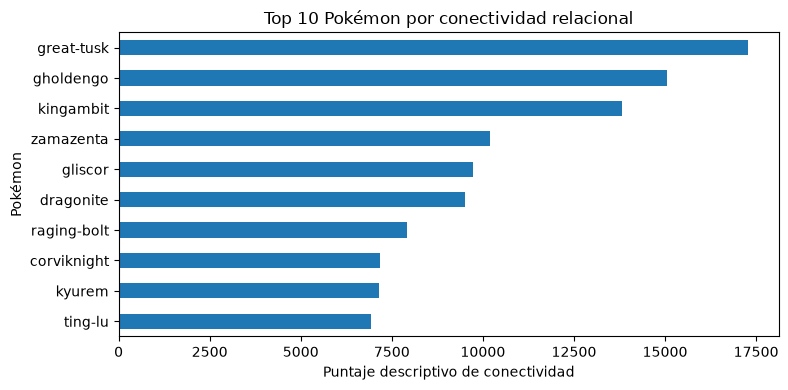

En los primeros lugares aparecen great-tusk, gholdengo y kingambit. Estos Pokémon quedan arriba porque agregan muchas conexiones observadas, pesos de co-uso, diversidad de compañeros y recursos competitivos asociados. En términos estratégicos, conviene leerlos como piezas con presencia relacional amplia: no necesariamente los mejores en combate, sino Pokémon que aparecen conectados con varias partes del grafo competitivo.

In [4]:
res = df('''
MATCH (p:Pokemon {is_default:true})
CALL {
  WITH p
  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)
  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones
  CALL {
    WITH aliados
    UNWIND aliados AS aliado
    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)
    RETURN count(DISTINCT tipo_aliado) AS diversidad_tipos_companeros
  }
  WITH aliados, relaciones, diversidad_tipos_companeros,
       reduce(total = 0.0, rel IN relaciones | total + coalesce(rel.pct, 1.0)) AS peso_total
  RETURN size(aliados) AS companeros_distintos,
         size(relaciones) AS relaciones_companero,
         round(peso_total * 100) / 100.0 AS peso_total_companeros,
         CASE WHEN size(relaciones) = 0 THEN 0.0
              ELSE round((peso_total / size(relaciones)) * 100) / 100.0
         END AS peso_promedio_companeros,
         diversidad_tipos_companeros
}
CALL {
  WITH p
  OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
  RETURN count(DISTINCT m) AS movimientos_usados
}
CALL {
  WITH p
  OPTIONAL MATCH (p)-[:USES_ABILITY]->(ab:Ability)
  RETURN count(DISTINCT ab) AS habilidades_usadas
}
CALL {
  WITH p
  OPTIONAL MATCH (p)-[:HOLDS_ITEM]->(it:Item)
  RETURN count(DISTINCT it) AS objetos_usados
}
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p,
     companeros_distintos,
     relaciones_companero,
     peso_total_companeros,
     peso_promedio_companeros,
     diversidad_tipos_companeros,
     movimientos_usados,
     habilidades_usadas,
     objetos_usados,
     coalesce(max(u.usage), 0.0) AS uso_smogon
WITH p,
     companeros_distintos,
     relaciones_companero,
     peso_total_companeros,
     peso_promedio_companeros,
     diversidad_tipos_companeros,
     movimientos_usados,
     habilidades_usadas,
     objetos_usados,
     uso_smogon,
     round((
       companeros_distintos * 2.0 +
       peso_total_companeros +
       diversidad_tipos_companeros * 1.5 +
       movimientos_usados * 0.5 +
       habilidades_usadas +
       objetos_usados
     ) * 100) / 100.0 AS puntaje_conectividad
RETURN p.identifier AS pokemon,
       companeros_distintos,
       relaciones_companero,
       peso_total_companeros,
       peso_promedio_companeros,
       diversidad_tipos_companeros,
       movimientos_usados,
       habilidades_usadas,
       objetos_usados,
       round(uso_smogon * 100) / 100.0 AS uso_smogon,
       puntaje_conectividad
ORDER BY puntaje_conectividad DESC, companeros_distintos DESC, peso_total_companeros DESC
LIMIT 20
''')
display(res)
if not res.empty:
    ax = res.head(10).sort_values('puntaje_conectividad').plot.barh(
        x='pokemon', y='puntaje_conectividad', legend=False, figsize=(8, 4)
    )
    ax.set_title('Top 10 Pokémon por conectividad relacional')
    ax.set_xlabel('Puntaje descriptivo de conectividad')
    ax.set_ylabel('Pokémon')
    plt.tight_layout()
    plt.show()
if not res.empty:
    nombres = lista_texto(res['pokemon'])
    display(Markdown(
        f"En los primeros lugares aparecen {nombres}. Estos Pokémon quedan arriba porque agregan muchas conexiones observadas, pesos de co-uso, "
        "diversidad de compañeros y recursos competitivos asociados. En términos estratégicos, conviene leerlos como piezas con presencia relacional amplia: "
        "no necesariamente los mejores en combate, sino Pokémon que aparecen conectados con varias partes del grafo competitivo."
    ))


En este análisis, la influencia no debe entenderse simplemente como
popularidad o fuerza individual. Aquí se mide como conectividad relacional
descriptiva: un Pokémon obtiene un valor más alto cuando aparece conectado con
muchos compañeros distintos, cuando esas relaciones tienen mayor peso observado
y cuando sus conexiones cubren una diversidad mayor de tipos y recursos. Todo se
calcula con consultas Cypher y agregaciones, sin PageRank ni modelos predictivos.

La tabla y el gráfico permiten identificar piezas que ayudan a organizar el
metajuego competitivo. Si un Pokémon aparece con alta conectividad, puede ser
porque encaja con muchos compañeros, porque tiene vínculos de co-uso más fuertes
o porque concentra recursos frecuentes. En términos prácticos, estos resultados
sirven para decidir qué amenazas conviene estudiar primero al preparar respuestas
defensivas o al analizar cómo se construyen equipos en el formato.

Esta medida depende de las relaciones cargadas desde Smogon y no incorpora por
sí sola detalles como objetos, EVs, movimientos específicos o decisiones dentro
de una partida. Por eso funciona como una señal inicial de influencia
estratégica, pero no reemplaza un análisis competitivo completo.


In [5]:
query = '''
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
OPTIONAL MATCH (p)-[:USES_ABILITY]->(ab:Ability)
OPTIONAL MATCH (p)-[:HOLDS_ITEM]->(it:Item)
RETURN p.identifier AS pokemon,
       round(u.usage * 100) / 100.0 AS uso_smogon,
       collect(DISTINCT m.identifier)[..5] AS movimientos_usados,
       collect(DISTINCT ab.identifier)[..3] AS habilidades_usadas,
       collect(DISTINCT it.identifier)[..3] AS objetos_usados
ORDER BY uso_smogon DESC
LIMIT 15
'''
res = df(query)
display(res)
if not res.empty:
    nombres = lista_texto(res['pokemon'])
    display(Markdown(
        f"En esta tabla destacan {nombres}, junto con una muestra de los movimientos, habilidades y objetos que aparecen asociados a ellos. "
        "La lectura relevante no es solo que estos Pokémon se usen, sino qué herramientas explican parte de ese uso. Si un Pokémon combina alto uso "
        "con recursos frecuentes, puede ser una amenaza que conviene preparar o una pieza que ayuda a sostener planes comunes de equipo."
    ))


,pokemon,uso_smogon,movimientos_usados,habilidades_usadas,objetos_usados
0,great-tusk,33.73,"[headlong-rush, knock-off, taunt, stealth-rock, rapid-spin]",[protosynthesis],"[choice-band, heavy-duty-boots, leftovers]"
1,zamazenta,28.68,"[body-press, stone-edge, reflect, close-combat, iron-defense]",[dauntless-shield],"[heavy-duty-boots, leftovers, choice-scarf]"
2,gholdengo,27.63,"[psyshock, dazzling-gleam, hex, thunder-wave, recover]",[good-as-gold],"[leftovers, shuca-berry, metal-coat]"
3,dragonite,25.35,"[dragon-claw, roost, outrage, low-kick, extreme-speed]",[multiscale],"[loaded-dice, choice-band, silk-scarf]"
4,kingambit,25.27,"[low-kick, swords-dance, iron-head, sucker-punch, kowtow-cleave]",[supreme-overlord],"[shuca-berry, black-glasses, leftovers]"
5,gliscor,19.39,"[earthquake, protect, stealth-rock, agility, toxic-spikes]",[poison-heal],[toxic-orb]
6,ting-lu,17.42,"[spikes, earthquake, protect, stealth-rock, taunt]",[vessel-of-ruin],"[leftovers, rocky-helmet, red-card]"
7,kyurem,17.04,"[ice-beam, focus-blast, earth-power, blizzard, dragon-dance]",[pressure],"[heavy-duty-boots, choice-specs, loaded-dice]"
8,ogerpon-wellspring-mask,16.47,"[substitute, encore, taunt, synthesis, trailblaze]",[water-absorb],[wellspring-mask]
9,dragapult,14.59,"[curse, draco-meteor, dragon-darts, quick-attack, thunder-wave]","[clear-body, infiltrator]","[choice-band, choice-specs, air-balloon]"


En esta tabla destacan great-tusk, zamazenta y gholdengo, junto con una muestra de los movimientos, habilidades y objetos que aparecen asociados a ellos. La lectura relevante no es solo que estos Pokémon se usen, sino qué herramientas explican parte de ese uso. Si un Pokémon combina alto uso con recursos frecuentes, puede ser una amenaza que conviene preparar o una pieza que ayuda a sostener planes comunes de equipo.

Esta tabla complementa la centralidad mostrando parte del kit competitivo de
los Pokémon más usados: movimientos, habilidades y objetos asociados. La idea es
pasar de "este Pokémon es importante" a una lectura más concreta sobre cómo
aporta valor dentro de un equipo. Un Pokémon puede ser central por su capacidad
de presionar, resistir, apoyar a compañeros o habilitar una secuencia común de
juego.

El resultado es útil porque permite conectar influencia con herramientas
observables. Si ciertos movimientos u objetos aparecen repetidamente, eso puede
orientar la preparación de respuestas defensivas y ayudar a entender qué recursos
definen el metajuego. Aun así, la tabla muestra una síntesis y no todos los
conjuntos posibles, por lo que debe leerse como una guía inicial y no como una
descripción completa de cada set competitivo.


#### Contraste entre uso competitivo e influencia en el grafo

El uso competitivo y la centralidad no miden lo mismo. El uso indica con qué
frecuencia aparece un Pokémon en los datos de Smogon, mientras que la
conectividad relacional resume cuántos compañeros distintos tiene, qué peso
tienen esas relaciones y qué diversidad de vínculos concentra. Por eso, un
Pokémon puede ser muy usado y estar concentrado en ciertos equipos, o puede
tener menor uso pero conectar varias zonas relevantes del grafo.


In [6]:
contraste = df('''
MATCH (p:Pokemon {is_default:true})
CALL {
  WITH p
  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)
  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones
  CALL {
    WITH aliados
    UNWIND aliados AS aliado
    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)
    RETURN count(DISTINCT tipo_aliado) AS diversidad_tipos_companeros
  }
  RETURN size(aliados) AS companeros_distintos,
         round(reduce(total = 0.0, rel IN relaciones | total + coalesce(rel.pct, 1.0)) * 100) / 100.0 AS peso_total_companeros,
         diversidad_tipos_companeros
}
CALL {
  WITH p
  OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
  RETURN count(DISTINCT m) AS movimientos_usados
}
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p.identifier AS pokemon,
     coalesce(max(u.usage), 0.0) AS uso_smogon,
     round((
       companeros_distintos * 2.0 +
       peso_total_companeros +
       diversidad_tipos_companeros * 1.5 +
       movimientos_usados * 0.5
     ) * 100) / 100.0 AS puntaje_conectividad
WITH collect({pokemon:pokemon, puntaje_conectividad:puntaje_conectividad, uso_smogon:uso_smogon}) AS filas
UNWIND filas AS r
WITH r, filas,
     1 + size([x IN filas WHERE x.uso_smogon > r.uso_smogon]) AS ranking_uso,
     1 + size([x IN filas WHERE x.puntaje_conectividad > r.puntaje_conectividad]) AS ranking_conectividad
WITH r.pokemon AS pokemon,
     round(r.uso_smogon * 100) / 100.0 AS uso_smogon,
     r.puntaje_conectividad AS puntaje_conectividad,
     ranking_uso,
     ranking_conectividad,
     ranking_uso - ranking_conectividad AS diferencia_ranking,
     abs(ranking_uso - ranking_conectividad) AS diferencia_absoluta
RETURN pokemon,
       uso_smogon,
       puntaje_conectividad,
       ranking_uso,
       ranking_conectividad,
       diferencia_ranking,
       CASE
         WHEN diferencia_ranking > 0 THEN 'Más central de lo que sugiere su uso'
         WHEN diferencia_ranking < 0 THEN 'Más usado que conectado en la red'
         ELSE 'Uso y centralidad alineados'
       END AS interpretacion
ORDER BY diferencia_absoluta DESC, puntaje_conectividad DESC
LIMIT 20
''')

display(contraste)
if not contraste.empty:
    corr = contraste[['uso_smogon', 'puntaje_conectividad']].corr().iloc[0, 1]
    muestra = lista_texto(contraste['pokemon'])
    display(Markdown(
        f"En esta muestra, la correlación entre uso y conectividad relacional es {corr:.3f}. Casos como {muestra} muestran dónde el ranking relacional se separa más del ranking por uso. "
        "Una diferencia positiva indica que el Pokémon aparece más central en la red de compañeros de lo que sugeriría su frecuencia bruta; una diferencia negativa indica lo contrario."
    ))


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=3, column=1, offset=37>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 37, 'line': 3, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon {is_default:true})\nCALL {\n  WITH p\n  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)\n  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones\n  CALL {\n    WITH aliados\n    UNWIND aliados AS aliado\n    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)\n    RETURN count(DISTINCT tipo_a

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (aliados) { ... }', position=<SummaryInputPosition line=7, column=3, offset=189>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 189, 'line': 7, 'column': 3}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon {is_default:true})\nCALL {\n  WITH p\n  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)\n  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones\n  CALL {\n    WITH aliados\n    UNWIND aliados AS aliado\n    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)\n    RETURN count(DISTINC

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=17, column=1, offset=591>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 591, 'line': 17, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon {is_default:true})\nCALL {\n  WITH p\n  OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)\n  WITH collect(DISTINCT aliado) AS aliados, collect(DISTINCT tm) AS relaciones\n  CALL {\n    WITH aliados\n    UNWIND aliados AS aliado\n    OPTIONAL MATCH (aliado)-[:HAS_TYPE]->(tipo_aliado:Type)\n    RETURN count(DISTINCT ti

,pokemon,uso_smogon,puntaje_conectividad,ranking_uso,ranking_conectividad,diferencia_ranking,interpretacion
0,reuniclus,0.09,53.2,124,187,-63,Más usado que conectado en la red
1,dudunsparce-two-segment,0.05,50.8,135,192,-57,Más usado que conectado en la red
2,chesnaught,0.23,63.0,99,146,-47,Más usado que conectado en la red
3,wo-chien,0.09,57.5,123,168,-45,Más usado que conectado en la red
4,torterra,0.03,46.2,156,199,-43,Más usado que conectado en la red
5,feraligatr,0.07,56.7,131,173,-42,Más usado que conectado en la red
6,regirock,0.01,61.5,194,153,41,Más central de lo que sugiere su uso
7,brambleghast,0.03,48.0,154,195,-41,Más usado que conectado en la red
8,registeel,0.01,59.6,198,158,40,Más central de lo que sugiere su uso
9,porygon-z,0.04,52.9,150,190,-40,Más usado que conectado en la red


En esta muestra, la correlación entre uso y conectividad relacional es 0.999. Casos como reuniclus, dudunsparce-two-segment y chesnaught muestran dónde el ranking relacional se separa más del ranking por uso. Una diferencia positiva indica que el Pokémon aparece más central en la red de compañeros de lo que sugeriría su frecuencia bruta; una diferencia negativa indica lo contrario.

Este contraste fortalece la lectura relacional del proyecto. Si el ranking por
conectividad fuera idéntico al ranking de uso, el grafo estaría aportando poco
más que una tabla de popularidad. Cuando ambos rankings se separan, aparece una
lectura más interesante: la consulta captura cómo se conecta una pieza con otras
piezas y recursos relevantes, no solo cuántas veces aparece en el formato.


### 4.2 Pokémon que podrían cumplir funciones parecidas

Jaccard es una forma simple de medir cuánto se parecen dos conjuntos. Aquí se
usa para comparar movimientos usados competitivamente (`RUNS_MOVE`), no el
learnset completo disponible por `CAN_LEARN`. Esto evita que la similitud quede
dominada por movimientos universales o poco relevantes. Además, se excluyen
Pokémon de una misma línea evolutiva y se agregan diferencias de estadísticas
para evaluar si la sustitución parece realista.


Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=2, column=26, offset=84>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 84, 'line': 2, 'column': 26}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:RUNS_MOVE]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movimientos_usados\nORDER BY movimientos_usados DESC\nLIMIT 80\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movimientos_usados, collect(DISTINCT t.identifier) AS tip

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=16, column=7, offset=763>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 763, 'line': 16, 'column': 7}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:RUNS_MOVE]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movimientos_usados\nORDER BY movimientos_usados DESC\nLIMIT 80\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movimientos_usados, collect(DISTINCT t.identifier) AS t

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=16, column=16, offset=772>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 772, 'line': 16, 'column': 16}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:RUNS_MOVE]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movimientos_usados\nORDER BY movimientos_usados DESC\nLIMIT 80\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movimientos_usados, collect(DISTINCT t.identifier) AS

,pokemon_a,pokemon_b,movimientos_compartidos,similitud_jaccard,tipos_compartidos,bst_a,bst_b,diferencia_bst,diferencia_promedio_stats
0,latias,latios,8,0.471,"[psychic, dragon]",600,600,0,10.00
1,gardevoir,hatterene,9,0.450,"[psychic, fairy]",518,510,8,23.33
2,regirock,garganacl,8,0.421,[rock],580,500,80,20.00
3,gengar,gholdengo,7,0.412,[ghost],500,550,50,18.67
4,kingdra,walking-wake,7,0.412,"[dragon, water]",540,590,50,17.67
5,slowbro,bronzong,8,0.364,[psychic],490,500,10,18.00
6,gardevoir,iron-valiant,9,0.360,[fairy],518,590,72,32.00
7,regirock,registeel,7,0.350,[],580,580,0,25.00
8,snorlax,regirock,7,0.350,[],540,580,40,45.00
9,gardevoir,latias,7,0.350,[psychic],518,600,82,18.67


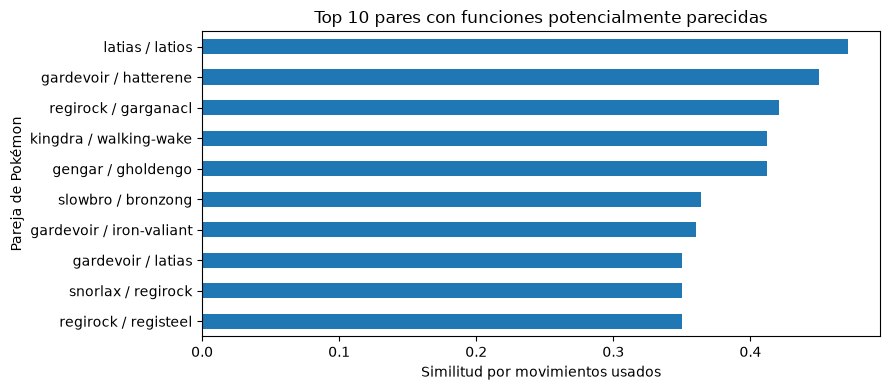

Entre los pares más altos aparecen latias / latios (Jaccard 0.471, diferencia BST 0); gardevoir / hatterene (Jaccard 0.45, diferencia BST 8); regirock / garganacl (Jaccard 0.421, diferencia BST 80). Estos casos suben en la tabla porque comparten movimientos observados en uso competitivo y, al mismo tiempo, permiten comparar si la diferencia de estadísticas base hace plausible la sustitución. Una pareja con alta similitud pero diferencia BST grande debe revisarse con más cuidado: puede parecerse en herramientas, pero no necesariamente cumplir el mismo rol en combate.

In [7]:
query = '''MATCH (p:Pokemon {is_default:true})-[:RUNS_MOVE]->(m:Move)
WITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movimientos_usados
ORDER BY movimientos_usados DESC
LIMIT 80
MATCH (p)-[:IS_SPECIES]->(sp:Species)
OPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)
WITH p, sp, moves, movimientos_usados, collect(DISTINCT t.identifier) AS tipos
OPTIONAL MATCH (p)-[hs:HAS_STAT]->(st:Stat)
WITH p, sp, moves, movimientos_usados, tipos,
     sum(coalesce(hs.base_stat, 0)) AS bst,
     collect({stat: st.identifier, valor: coalesce(hs.base_stat, 0)}) AS stats
WITH collect({p:p, sp:sp, moves:moves, size:movimientos_usados, tipos:tipos, bst:bst, stats:stats}) AS pokes
UNWIND pokes AS a
UNWIND pokes AS b
WITH a, b, a.p AS pa, b.p AS pb, a.sp AS spa, b.sp AS spb
WHERE id(pa) < id(pb)
  AND NOT EXISTS {
    MATCH (spa)-[:EVOLVES_TO*1..10]-(spb)
  }
WITH a, b, size([x IN a.moves WHERE x IN b.moves]) AS inter
WHERE inter >= 2
WITH a, b, inter,
     toFloat(inter) / (a.size + b.size - inter) AS jaccard
WITH a, b, inter, jaccard,
     [sa IN a.stats
      WHERE any(sb IN b.stats WHERE sb.stat = sa.stat)
      | abs(sa.valor - head([sb IN b.stats WHERE sb.stat = sa.stat | sb.valor]))] AS diferencias_stats
RETURN a.p.identifier AS pokemon_a,
       b.p.identifier AS pokemon_b,
       inter AS movimientos_compartidos,
       round(jaccard * 1000) / 1000.0 AS similitud_jaccard,
       [tipo IN a.tipos WHERE tipo IN b.tipos] AS tipos_compartidos,
       a.bst AS bst_a,
       b.bst AS bst_b,
       abs(a.bst - b.bst) AS diferencia_bst,
       CASE WHEN size(diferencias_stats) = 0 THEN null
            ELSE round((reduce(total = 0.0, d IN diferencias_stats | total + d) / size(diferencias_stats)) * 100) / 100.0
       END AS diferencia_promedio_stats
ORDER BY similitud_jaccard DESC, movimientos_compartidos DESC
LIMIT 20
'''
res = df(query)
display(res)
if not res.empty:
    graf = res.head(10).copy()
    graf['pareja'] = graf['pokemon_a'] + ' / ' + graf['pokemon_b']
    ax = graf.sort_values('similitud_jaccard').plot.barh(
        x='pareja', y='similitud_jaccard', legend=False, figsize=(9, 4)
    )
    ax.set_title('Top 10 pares con funciones potencialmente parecidas')
    ax.set_xlabel('Similitud por movimientos usados')
    ax.set_ylabel('Pareja de Pokémon')
    plt.tight_layout()
    plt.show()
if not res.empty:
    top = res.head(3).copy()
    pares = "; ".join(
        f"{r.pokemon_a} / {r.pokemon_b} (Jaccard {r.similitud_jaccard}, diferencia BST {r.diferencia_bst})"
        for r in top.itertuples()
    )
    display(Markdown(
        f"Entre los pares más altos aparecen {pares}. Estos casos suben en la tabla porque comparten movimientos observados en uso competitivo y, al mismo tiempo, "
        "permiten comparar si la diferencia de estadísticas base hace plausible la sustitución. Una pareja con alta similitud pero diferencia BST grande "
        "debe revisarse con más cuidado: puede parecerse en herramientas, pero no necesariamente cumplir el mismo rol en combate."
    ))


La similitud entre Pokémon se calcula comparando movimientos usados en la capa
competitiva disponible. En términos simples, dos Pokémon aparecen más arriba
cuando comparten herramientas que no solo existen en su learnset, sino que
también fueron registradas como parte de su uso competitivo. Esto no significa
que sean idénticos, pero sí que podrían cumplir funciones parecidas, como aportar
una cobertura similar, usar movimientos de apoyo comparables o adaptarse a planes
de equipo relacionados.

La comparación de estadísticas agrega una segunda capa de lectura. El total de
estadísticas base (`bst_a` y `bst_b`) y las diferencias promedio ayudan a evaluar
si la sustitución es realista: dos Pokémon pueden aprender movimientos parecidos,
pero si uno tiene mucha más velocidad, bulk o poder ofensivo que el otro, la
alternativa puede funcionar peor en la práctica. También se excluyen evoluciones
y pre-evoluciones, porque normalmente no son sustitutos estratégicos útiles,
sino versiones relacionadas de una misma línea.

El resultado debe entenderse como una lista de candidatos para revisar, no como
una recomendación automática. Aunque `RUNS_MOVE` es más informativo que
`CAN_LEARN`, todavía faltan factores importantes como EVs, naturalezas, objetos,
habilidades específicas y rol dentro del equipo. El valor del grafo está en
reducir el espacio de búsqueda y proponer comparaciones razonables que luego
requieren juicio competitivo.


#### Sustitutos con mayor señal competitiva

La tabla anterior busca parecido funcional. Esta segunda tabla agrega una
exigencia adicional: al menos uno de los dos Pokémon debe tener presencia en la
capa competitiva, ya sea por uso en el formato o por conexiones en la red de
compañeros `TEAMMATE_OF`. Así se priorizan alternativas que no solo se parecen
por movimientos usados y estadísticas, sino que además tienen alguna señal de
relevancia en el grafo competitivo.


Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=2, column=26, offset=84>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 84, 'line': 2, 'column': 26}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:RUNS_MOVE]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movimientos_usados\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movimientos_usados, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves, movim

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=21, column=7, offset=1202>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1202, 'line': 21, 'column': 7}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:RUNS_MOVE]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movimientos_usados\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movimientos_usados, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves, m

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=21, column=16, offset=1211>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1211, 'line': 21, 'column': 16}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:RUNS_MOVE]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movimientos_usados\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movimientos_usados, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves,

,pokemon_a,pokemon_b,pokemon_competitivo,movimientos_compartidos,similitud_jaccard,bst_a,bst_b,diferencia_bst,diferencia_promedio_stats,conexiones_team_a,conexiones_team_b,conexiones_team_total
0,hatterene,iron-crown,hatterene / iron-crown,6,0.333,510,590,80,24.00,84,35,119
1,mandibuzz,corviknight,mandibuzz / corviknight,4,0.333,510,495,15,9.83,24,87,111
2,zapdos,pelipper,zapdos / pelipper,4,0.308,580,440,140,28.33,45,45,90
3,rillaboom,ogerpon,rillaboom / ogerpon,4,0.308,530,550,20,13.67,51,21,72
4,rillaboom,lokix,rillaboom / lokix,3,0.300,530,450,80,15.67,51,26,77
5,moltres,pelipper,moltres / pelipper,3,0.300,580,440,140,26.67,26,45,71
6,pelipper,mandibuzz,pelipper / mandibuzz,3,0.300,440,510,70,25.00,45,24,69
7,zapdos,raging-bolt,zapdos / raging-bolt,5,0.294,580,590,10,16.00,45,66,111
8,ninetales,torkoal,ninetales / torkoal,5,0.294,505,470,35,31.83,30,29,59
9,latias,iron-crown,latias / iron-crown,5,0.294,600,590,10,12.33,22,35,57


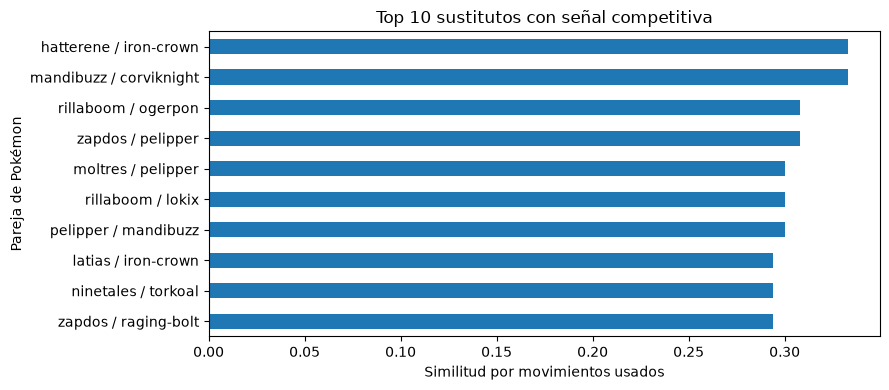

Con la restricción competitiva, los primeros pares son hatterene / iron-crown (señal: hatterene / iron-crown, conexiones 84+35); mandibuzz / corviknight (señal: mandibuzz / corviknight, conexiones 24+87); zapdos / pelipper (señal: zapdos / pelipper, conexiones 45+45). Esta tabla es más exigente que la anterior porque no basta con compartir movimientos: al menos una de las dos piezas debe estar conectada con la capa competitiva, ya sea por presencia en equipos o por vínculos en `TEAMMATE_OF`. Por eso estos pares son candidatos más cercanos a una discusión de construcción real.

In [8]:
query = '''MATCH (p:Pokemon {is_default:true})-[:RUNS_MOVE]->(m:Move)
WITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movimientos_usados
OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)
WITH p, moves, movimientos_usados, count(DISTINCT tm) AS conexiones_team
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p, moves, movimientos_usados, conexiones_team, coalesce(max(u.usage), 0.0) AS uso_smogon
ORDER BY conexiones_team DESC, uso_smogon DESC, movimientos_usados DESC
LIMIT 60
MATCH (p)-[:IS_SPECIES]->(sp:Species)
OPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)
WITH p, sp, moves, movimientos_usados, conexiones_team, uso_smogon, collect(DISTINCT t.identifier) AS tipos
OPTIONAL MATCH (p)-[hs:HAS_STAT]->(st:Stat)
WITH p, sp, moves, movimientos_usados, conexiones_team, uso_smogon, tipos,
     sum(coalesce(hs.base_stat, 0)) AS bst,
     collect({stat: st.identifier, valor: coalesce(hs.base_stat, 0)}) AS stats
WITH collect({p:p, sp:sp, moves:moves, size:movimientos_usados, tipos:tipos, bst:bst, stats:stats,
              conexiones_team:conexiones_team, uso_smogon:uso_smogon}) AS pokes
UNWIND pokes AS a
UNWIND pokes AS b
WITH a, b, a.p AS pa, b.p AS pb, a.sp AS spa, b.sp AS spb
WHERE id(pa) < id(pb)
  AND (a.conexiones_team > 0 OR b.conexiones_team > 0 OR a.uso_smogon > 0 OR b.uso_smogon > 0)
  AND NOT EXISTS {
    MATCH (spa)-[:EVOLVES_TO*1..10]-(spb)
  }
WITH a, b, size([x IN a.moves WHERE x IN b.moves]) AS inter
WHERE inter >= 2
WITH a, b, inter,
     toFloat(inter) / (a.size + b.size - inter) AS jaccard
WITH a, b, inter, jaccard,
     [sa IN a.stats
      WHERE any(sb IN b.stats WHERE sb.stat = sa.stat)
      | abs(sa.valor - head([sb IN b.stats WHERE sb.stat = sa.stat | sb.valor]))] AS diferencias_stats
WITH a, b, inter, jaccard, diferencias_stats,
     a.conexiones_team + b.conexiones_team AS conexiones_team_total
RETURN a.p.identifier AS pokemon_a,
       b.p.identifier AS pokemon_b,
       CASE
         WHEN (a.conexiones_team > 0 OR a.uso_smogon > 0) AND (b.conexiones_team > 0 OR b.uso_smogon > 0)
           THEN a.p.identifier + ' / ' + b.p.identifier
         WHEN a.conexiones_team > 0 OR a.uso_smogon > 0 THEN a.p.identifier
         ELSE b.p.identifier
       END AS pokemon_competitivo,
       inter AS movimientos_compartidos,
       round(jaccard * 1000) / 1000.0 AS similitud_jaccard,
       a.bst AS bst_a,
       b.bst AS bst_b,
       abs(a.bst - b.bst) AS diferencia_bst,
       CASE WHEN size(diferencias_stats) = 0 THEN null
            ELSE round((reduce(total = 0.0, d IN diferencias_stats | total + d) / size(diferencias_stats)) * 100) / 100.0
       END AS diferencia_promedio_stats,
       a.conexiones_team AS conexiones_team_a,
       b.conexiones_team AS conexiones_team_b,
       conexiones_team_total AS conexiones_team_total
ORDER BY similitud_jaccard DESC, conexiones_team_total DESC, movimientos_compartidos DESC
LIMIT 20
'''
res_comp = df(query)
display(res_comp)
if not res_comp.empty:
    graf = res_comp.head(10).copy()
    graf['pareja'] = graf['pokemon_a'] + ' / ' + graf['pokemon_b']
    ax = graf.sort_values('similitud_jaccard').plot.barh(
        x='pareja', y='similitud_jaccard', legend=False, figsize=(9, 4)
    )
    ax.set_title('Top 10 sustitutos con señal competitiva')
    ax.set_xlabel('Similitud por movimientos usados')
    ax.set_ylabel('Pareja de Pokémon')
    plt.tight_layout()
    plt.show()
    pares = "; ".join(
        f"{r.pokemon_a} / {r.pokemon_b} (señal: {r.pokemon_competitivo}, conexiones {r.conexiones_team_a}+{r.conexiones_team_b})"
        for r in res_comp.head(3).itertuples()
    )
    display(Markdown(
        f"Con la restricción competitiva, los primeros pares son {pares}. Esta tabla es más exigente que la anterior porque no basta con compartir movimientos: "
        "al menos una de las dos piezas debe estar conectada con la capa competitiva, ya sea por presencia en equipos o por vínculos en `TEAMMATE_OF`. "
        "Por eso estos pares son candidatos más cercanos a una discusión de construcción real."
    ))


Esta segunda tabla no reemplaza a la primera: la complementa. La primera
permite descubrir parecidos funcionales amplios, mientras que esta filtra esos
parecidos hacia casos con mayor evidencia competitiva. Si un par mantiene alta
similitud por movimientos usados, diferencias razonables de estadísticas y además uno
de sus integrantes aparece conectado en la red de equipos, la comparación se
vuelve más interesante para discutir alternativas reales.

La lectura sigue requiriendo cautela. Las conexiones en `TEAMMATE_OF` indican
presencia relacional en el metajuego cargado, pero no explican por sí solas el
conjunto, el objeto ni el rol exacto. Por eso la tabla sirve para priorizar pares
que merecen revisión, no para afirmar automáticamente que un Pokémon reemplaza
al otro en cualquier equipo.


### 4.3 Contexto estructural de tipos: perfiles ofensivos y defensivos

Esta sección separa los perfiles de un solo tipo y de dos tipos para que la
lectura sea más clara. La idea es distinguir cobertura ofensiva, es decir, a qué
tipos o combinaciones puede presionar un perfil, de cobertura defensiva, es
decir, qué ataques recibe como daño reducido, neutral o súper efectivo.

Antes de calcular estas métricas se revisa qué información existe en el grafo.
En este proyecto, `SUPER_EFFECTIVE` representa solo ventajas x2, mientras que
`EFFECTIVENESS.factor` contiene el cuadro completo de multiplicadores. Por eso
se pueden calcular daño normal x1, resistencias x0.5 y resistencias dobles
x0.25 sin inventar relaciones nuevas. Metodológicamente, esta sección no debe
leerse como un gran descubrimiento competitivo: gran parte de la efectividad de
tipos proviene de reglas conocidas del juego. El valor del grafo está en cruzar
esas reglas con Pokémon reales de la base, combinaciones observadas y ejemplos
concretos que vuelven la lectura más útil para el análisis del metajuego.


#### Cómo leer las columnas de cobertura

En las tablas siguientes, `cantidad_pokemon` sí indica cuántos Pokémon de la base
tienen ese perfil de tipo. En cambio, las columnas ofensivas no cuentan Pokémon:
cuentan tipos o combinaciones de tipos contra los que el perfil puede atacar con
cierta efectividad. Por ejemplo, `objetivos_ofensivos_x2` cuenta objetivos a los
que el perfil golpea de forma súper efectiva, mientras que
`combinaciones_objetivo_x4` cuenta combinaciones reales de dos tipos que pueden
recibir una presión híper efectiva.

Las columnas defensivas tampoco cuentan Pokémon. Resumen cuántos tipos ofensivos
representan amenazas, daño neutral o resistencias frente al perfil analizado.
`x2` significa súper efectivo, `x4` significa híper efectivo, `x0.5` indica
resistencia, `x0.25` indica resistencia doble y `x1` corresponde a daño normal o
neutral, no a resistencia. Finalmente, `balance_ajustado` es un puntaje
interpretativo para comparar perfiles de tipo; no es una métrica oficial del
juego ni reemplaza cálculos de daño reales.


In [9]:
efectividad = df('''
MATCH (atk:Type)-[r:EFFECTIVENESS]->(def:Type)
RETURN atk.identifier AS atacante, def.identifier AS defensor, r.factor AS factor
ORDER BY atacante, defensor
LIMIT 400
''')

tipos_pokemon = df('''
MATCH (p:Pokemon {is_default:true})-[:HAS_TYPE]->(t:Type)
RETURN p.identifier AS pokemon, t.identifier AS tipo
ORDER BY pokemon, tipo
LIMIT 3000
''')

factores = sorted(efectividad['factor'].dropna().astype(int).unique().tolist())
efectividad_completa = all(f in factores for f in [50, 100, 200])
display(pd.DataFrame([{
    'relacion': 'EFFECTIVENESS',
    'factores_observados': factores,
    'permite_x05_x025_x1': efectividad_completa
}]))

tipos = sorted(set(efectividad['atacante']) | set(efectividad['defensor']))
factor_map = {
    (r.atacante, r.defensor): int(r.factor) / 100.0
    for r in efectividad.itertuples()
}

def mult(atacante, defensor):
    return factor_map.get((atacante, defensor), 1.0)

nombres_cobertura = {
    'ofensiva_x2': 'objetivos_ofensivos_x2',
    'ofensiva_x4': 'combinaciones_objetivo_x4',
    'ofensiva_x1': 'objetivos_ofensivos_neutrales_x1',
    'debilidades_x2': 'amenazas_defensivas_x2',
    'debilidades_x4': 'amenazas_defensivas_x4',
    'amenazas_x4': 'tipos_amenaza_x4',
    'defensiva_x05': 'resistencias_defensivas_x05',
    'defensiva_x025': 'resistencias_defensivas_x025',
    'resistencias_x025': 'tipos_resistidos_x025',
    'defensiva_x1': 'amenazas_neutrales_x1',
}

def mostrar_columnas_claras(tabla, columnas, n=15):
    return tabla[columnas].head(n).rename(columns=nombres_cobertura)

tipos_por_pokemon = (
    tipos_pokemon.groupby('pokemon')['tipo']
    .apply(lambda s: sorted(set(s)))
    .reset_index(name='tipos')
)
tipos_por_pokemon['perfil_tipo'] = tipos_por_pokemon['tipos'].apply(lambda xs: ' / '.join(xs))

perfil_ejemplos = (
    tipos_por_pokemon.groupby('perfil_tipo')['pokemon']
    .apply(lambda s: ', '.join(list(s)[:5]))
    .to_dict()
)
perfil_cantidad = tipos_por_pokemon.groupby('perfil_tipo')['pokemon'].count().to_dict()
perfiles_individuales = sorted([xs[0] for xs in tipos_por_pokemon['tipos'] if len(xs) == 1])
perfiles_dobles = sorted({tuple(xs) for xs in tipos_por_pokemon['tipos'] if len(xs) == 2})

def ofensiva_basica(tipos_ofensivos):
    mejores = {defensor: max(mult(atk, defensor) for atk in tipos_ofensivos) for defensor in tipos}
    return {
        'ofensiva_x2': sum(1 for v in mejores.values() if v == 2.0),
        'ofensiva_x1': sum(1 for v in mejores.values() if v == 1.0),
    }

def defensiva(tipos_defensivos):
    valores = {}
    for atacante in tipos:
        total = 1.0
        for defensor in tipos_defensivos:
            total *= mult(atacante, defensor)
        valores[atacante] = total
    return valores

def ofensiva_x4_contra_combos(tipos_ofensivos):
    combos = []
    afectados = []
    for d1, d2 in perfiles_dobles:
        perfil = f'{d1} / {d2}'
        for atk in tipos_ofensivos:
            if mult(atk, d1) == 2.0 and mult(atk, d2) == 2.0:
                combos.append(perfil)
                afectados.extend(perfil_ejemplos.get(perfil, '').split(', '))
                break
    combos = sorted(set(c for c in combos if c))
    afectados = sorted(set(p for p in afectados if p))
    return combos, afectados

filas_ind = []
for perfil in sorted(set(perfiles_individuales)):
    off = ofensiva_basica([perfil])
    defs = defensiva([perfil])
    defensiva_x05 = sum(1 for v in defs.values() if v == 0.5)
    defensiva_x1 = sum(1 for v in defs.values() if v == 1.0)
    debilidades_x2 = sum(1 for v in defs.values() if v == 2.0)
    balance_tipo = off['ofensiva_x2'] + defensiva_x05 - debilidades_x2
    filas_ind.append({
        'perfil_tipo': perfil,
        'cantidad_pokemon': perfil_cantidad.get(perfil, 0),
        'ofensiva_x2': off['ofensiva_x2'],
        'ofensiva_x1': off['ofensiva_x1'],
        'defensiva_x05': defensiva_x05,
        'defensiva_x1': defensiva_x1,
        'debilidades_x2': debilidades_x2,
        'balance_tipo': balance_tipo,
        'balance_ajustado': balance_tipo,
        'ejemplos_pokemon': perfil_ejemplos.get(perfil, '')
    })

tabla_individual = pd.DataFrame(filas_ind).sort_values(
    ['balance_ajustado', 'ofensiva_x2', 'defensiva_x05'],
    ascending=False
).reset_index(drop=True)


,relacion,factores_observados,permite_x05_x025_x1
0,EFFECTIVENESS,"[0, 50, 100, 200]",True


#### 4.3.1 Perfiles de Pokémon de un solo tipo

En los Pokémon de un solo tipo, la lectura es directa: el perfil ofensivo depende
de lo que ese tipo puede golpear x2, mientras que el perfil defensivo depende de
qué tipos ofensivos le hacen daño reducido, neutral o súper efectivo. Aquí no se
incluyen debilidades x4 ni resistencias x0.25 porque esas situaciones aparecen
por combinación de dos tipos.


,perfil_tipo,cantidad_pokemon,objetivos_ofensivos_x2,objetivos_ofensivos_neutrales_x1,resistencias_defensivas_x05,amenazas_neutrales_x1,amenazas_defensivas_x2,balance_tipo,ejemplos_pokemon
0,steel,10,3,11,10,4,3,10,"copperajah, cufant, klang, klink, klinklang"
1,fire,36,4,10,6,9,3,7,"arcanine, braixen, charcadet, charmander, charmeleon"
2,fighting,28,5,7,3,12,3,5,"clobbopus, conkeldurr, crabrawler, falinks, grapploct"
3,water,74,3,12,4,12,2,5,"alomomola, arrokuda, barraskewda, basculin-red-striped, blastoise"
4,poison,16,2,11,5,11,2,5,"arbok, ekans, garbodor, grimer, gulpin"
5,ground,17,5,10,2,12,3,4,"cubone, diglett, donphan, drilbur, dugtrio"
6,fairy,21,3,12,3,12,2,4,"alcremie, aromatisse, clefable, clefairy, cleffa"
7,electric,35,2,12,3,14,1,4,"ampharos, bellibolt, blitzle, boltund, eelektrik"
8,rock,17,4,11,4,9,5,3,"boldore, bonsly, cranidos, garganacl, gigalith"
9,bug,23,3,8,3,12,3,3,"accelgor, blipbug, burmy, cascoon, caterpie"


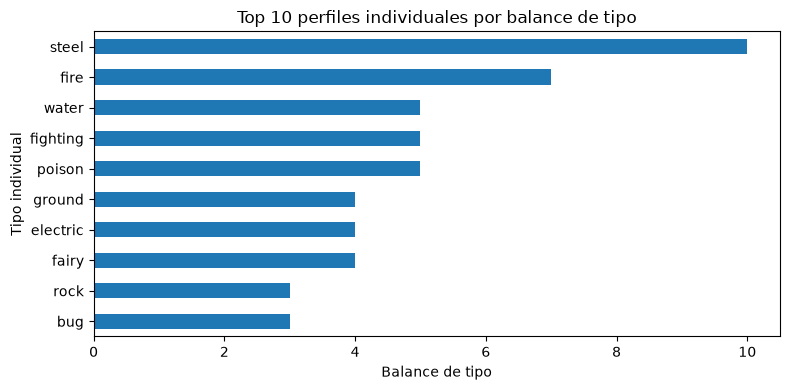

Entre los perfiles individuales mejor ubicados aparecen steel, fire y fighting. Estos tipos quedan arriba porque combinan buena cobertura x2, resistencias x0.5 y pocas debilidades x2. El balance de tipo no mide daño real ni sets concretos; funciona como una lectura resumida del intercambio entre presión ofensiva y seguridad defensiva. En una fila de esta tabla, `cantidad_pokemon` indica cuántos Pokémon tienen ese tipo, mientras que las columnas de cobertura resumen interacciones contra tipos: objetivos ofensivos, amenazas defensivas, resistencias y daño neutral. La contribución del grafo está en mostrar cuántos Pokémon concretos tienen cada perfil, no en redescubrir reglas de efectividad ya conocidas.

In [10]:
columnas_individuales = [
    'perfil_tipo', 'cantidad_pokemon',
    'ofensiva_x2', 'ofensiva_x1',
    'defensiva_x05', 'defensiva_x1',
    'debilidades_x2', 'balance_tipo',
    'ejemplos_pokemon'
]
display(mostrar_columnas_claras(tabla_individual, columnas_individuales, n=15))

if not tabla_individual.empty:
    ax = tabla_individual.head(10).sort_values('balance_tipo').plot.barh(
        x='perfil_tipo', y='balance_tipo', legend=False, figsize=(8, 4)
    )
    ax.set_title('Top 10 perfiles individuales por balance de tipo')
    ax.set_xlabel('Balance de tipo')
    ax.set_ylabel('Tipo individual')
    plt.tight_layout()
    plt.show()
    perfiles = lista_texto(tabla_individual['perfil_tipo'])
    display(Markdown(
        f"Entre los perfiles individuales mejor ubicados aparecen {perfiles}. Estos tipos quedan arriba porque combinan buena cobertura x2, "
        "resistencias x0.5 y pocas debilidades x2. El balance de tipo no mide daño real ni sets concretos; funciona como una lectura resumida "
        "del intercambio entre presión ofensiva y seguridad defensiva. En una fila de esta tabla, `cantidad_pokemon` indica cuántos Pokémon tienen ese tipo, "
        "mientras que las columnas de cobertura resumen interacciones contra tipos: objetivos ofensivos, amenazas defensivas, resistencias y daño neutral. "
        "La contribución del grafo está en mostrar cuántos Pokémon concretos tienen cada perfil, no en redescubrir reglas de efectividad ya conocidas."
    ))


#### 4.3.2 Perfiles de Pokémon de dos tipos

Los Pokémon de dos tipos tienen una lectura más rica, pero también más riesgosa.
Una combinación puede ampliar la cobertura ofensiva y sumar resistencias, aunque
también puede crear debilidades x4 cuando un mismo tipo atacante es súper
efectivo contra ambos tipos defensivos. Por eso se agrega un balance ajustado
que premia cobertura y resistencias, pero penaliza con más fuerza las
vulnerabilidades dobles.


,perfil_tipo,cantidad_pokemon,objetivos_ofensivos_x2,combinaciones_objetivo_x4,amenazas_defensivas_x2,amenazas_defensivas_x4,tipos_amenaza_x4,resistencias_defensivas_x025,tipos_resistidos_x025,balance_ajustado,ejemplos_pokemon
0,fire / ground,2,8,14,1,1,water,0,,25,"camerupt, numel"
1,ground / steel,3,7,11,4,0,,1,rock,22,"excadrill, iron-treads, steelix"
2,ground / rock,9,8,14,4,2,"grass, water",1,poison,21,"geodude, golem, graveler, larvitar, onix"
3,flying / ground,3,8,12,1,1,ice,0,,21,"gligar, gliscor, landorus-incarnate"
4,ground / ice,3,9,15,5,0,,0,,20,"mamoswine, piloswine, swinub"
5,fighting / ground,1,8,14,6,0,,1,rock,20,great-tusk
6,fighting / fire,6,7,11,4,0,,1,bug,20,"blaziken, combusken, emboar, infernape, monferno"
7,ground / water,9,6,11,0,1,grass,0,,20,"barboach, gastrodon, marshtomp, palpitoad, quagsire"
8,bug / ground,1,8,12,4,0,,0,,19,nincada
9,fire / steel,1,6,7,2,1,ground,5,"bug, fairy, grass, ice, steel",19,heatran


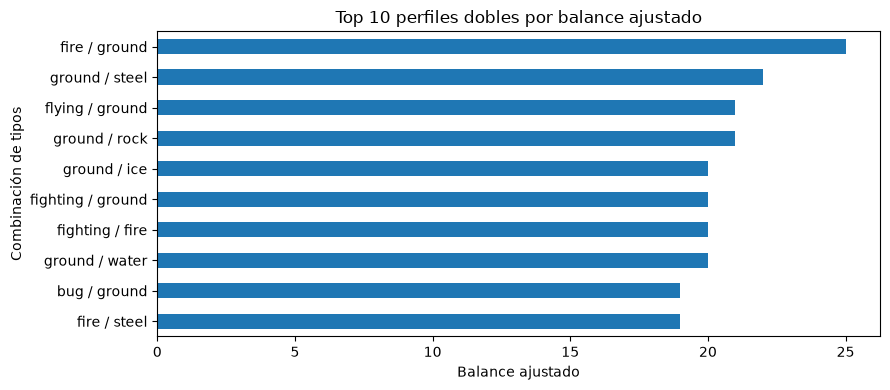

Entre las combinaciones dobles mejor ubicadas aparecen fire / ground, ground / steel y ground / rock. Estas combinaciones suelen quedar arriba porque suman cobertura ofensiva, resistencias útiles y pocas amenazas x4. Una debilidad x4 pesa más que una debilidad x2 porque marca un punto de entrada especialmente peligroso para el rival; por eso el balance ajustado la penaliza explícitamente. En una fila como `fire / ground`, `cantidad_pokemon` cuenta cuántos Pokémon tienen esa combinación, mientras que las demás columnas resumen interacciones de tipo: qué puede golpear, qué lo amenaza y si existen riesgos críticos x4 o resistencias fuertes x0.25. Esta lectura sirve como contexto estructural para discutir equipos, pero no reemplaza el análisis de movimientos, habilidades, objetos ni roles.

In [11]:
filas_dobles = []
for t1, t2 in perfiles_dobles:
    perfil = f'{t1} / {t2}'
    off = ofensiva_basica([t1, t2])
    combos_x4, _ = ofensiva_x4_contra_combos([t1, t2])
    defs = defensiva([t1, t2])
    debilidades_x2 = sum(1 for v in defs.values() if v == 2.0)
    debilidades_x4 = sum(1 for v in defs.values() if v == 4.0)
    amenazas_x4 = sorted([atk for atk, v in defs.items() if v == 4.0])
    defensiva_x05 = sum(1 for v in defs.values() if v == 0.5)
    defensiva_x025 = sum(1 for v in defs.values() if v == 0.25)
    resistencias_x025 = sorted([atk for atk, v in defs.items() if v == 0.25])
    defensiva_x1 = sum(1 for v in defs.values() if v == 1.0)
    balance_tipo = off['ofensiva_x2'] - debilidades_x2
    balance_ajustado = (
        off['ofensiva_x2'] + len(combos_x4)
        - debilidades_x2 - debilidades_x4
        + defensiva_x05 + defensiva_x025
    )
    filas_dobles.append({
        'perfil_tipo': perfil,
        'cantidad_pokemon': perfil_cantidad.get(perfil, 0),
        'ofensiva_x2': off['ofensiva_x2'],
        'ofensiva_x4': len(combos_x4),
        'ofensiva_x1': off['ofensiva_x1'],
        'debilidades_x2': debilidades_x2,
        'debilidades_x4': debilidades_x4,
        'amenazas_x4': ', '.join(amenazas_x4),
        'defensiva_x05': defensiva_x05,
        'defensiva_x025': defensiva_x025,
        'resistencias_x025': ', '.join(resistencias_x025),
        'defensiva_x1': defensiva_x1,
        'balance_tipo': balance_tipo,
        'balance_ajustado': balance_ajustado,
        'ejemplos_pokemon': perfil_ejemplos.get(perfil, '')
    })

tabla_doble = pd.DataFrame(filas_dobles).sort_values(
    ['balance_ajustado', 'ofensiva_x4', 'debilidades_x4'],
    ascending=[False, False, True]
).reset_index(drop=True)

columnas_dobles = [
    'perfil_tipo', 'cantidad_pokemon',
    'ofensiva_x2', 'ofensiva_x4',
    'debilidades_x2', 'debilidades_x4', 'amenazas_x4',
    'defensiva_x025', 'resistencias_x025',
    'balance_ajustado', 'ejemplos_pokemon'
]
display(mostrar_columnas_claras(tabla_doble, columnas_dobles, n=15))

if not tabla_doble.empty:
    ax = tabla_doble.head(10).sort_values('balance_ajustado').plot.barh(
        x='perfil_tipo', y='balance_ajustado', legend=False, figsize=(9, 4)
    )
    ax.set_title('Top 10 perfiles dobles por balance ajustado')
    ax.set_xlabel('Balance ajustado')
    ax.set_ylabel('Combinación de tipos')
    plt.tight_layout()
    plt.show()
    perfiles = lista_texto(tabla_doble['perfil_tipo'])
    display(Markdown(
        f"Entre las combinaciones dobles mejor ubicadas aparecen {perfiles}. Estas combinaciones suelen quedar arriba porque suman cobertura ofensiva, "
        "resistencias útiles y pocas amenazas x4. Una debilidad x4 pesa más que una debilidad x2 porque marca un punto de entrada especialmente peligroso "
        "para el rival; por eso el balance ajustado la penaliza explícitamente. En una fila como `fire / ground`, `cantidad_pokemon` cuenta cuántos Pokémon "
        "tienen esa combinación, mientras que las demás columnas resumen interacciones de tipo: qué puede golpear, qué lo amenaza y si existen riesgos críticos x4 "
        "o resistencias fuertes x0.25. Esta lectura sirve como contexto estructural para discutir equipos, pero no reemplaza el análisis de movimientos, habilidades, objetos ni roles."
    ))


#### 4.3.3 Ventajas ofensivas x4 contra combinaciones reales

Una ventaja x4 aparece cuando un tipo ofensivo golpea súper efectivo a los dos
tipos de una combinación defensiva real. Esta vista es importante porque un tipo
puede no solo tener buena cobertura x2, sino además castigar de forma mucho más
fuerte a perfiles dobles concretos presentes en el grafo.


,tipo_ofensivo,combinaciones_x4,ejemplos_combinaciones,ejemplos_pokemon_afectados
0,ground,9,"electric / poison, electric / rock, electric / steel, fire / poison, fire / rock","aggron, aron, bastiodon, carkol, coalossal"
1,fighting,6,"dark / ice, dark / normal, dark / rock, dark / steel, ice / rock","aggron, amaura, aron, aurorus, bastiodon"
2,ice,6,"dragon / flying, dragon / grass, dragon / ground, flying / grass, flying / ground","altaria, appletun, applin, dartrix, dipplin"
3,fire,5,"bug / grass, bug / ice, bug / steel, grass / ice, grass / steel","abomasnow, durant, escavalier, ferroseed, ferrothorn"
4,rock,5,"bug / fire, bug / flying, bug / ice, fire / flying, flying / ice","articuno, beautifly, butterfree, centiskorch, charizard"
5,bug,3,"dark / grass, dark / psychic, grass / psychic","brute-bonnet, cacturne, calyrex, celebi, exeggcute"
6,fairy,3,"dark / dragon, dark / fighting, dragon / fighting","deino, guzzlord, hakamo-o, hydreigon, kommo-o"
7,flying,3,"bug / fighting, bug / grass, fighting / grass","breloom, buzzwole, chesnaught, heracross, leavanny"
8,grass,3,"ground / rock, ground / water, rock / water","barbaracle, barboach, binacle, carracosta, corsola"
9,water,3,"fire / ground, fire / rock, ground / rock","camerupt, carkol, coalossal, geodude, golem"


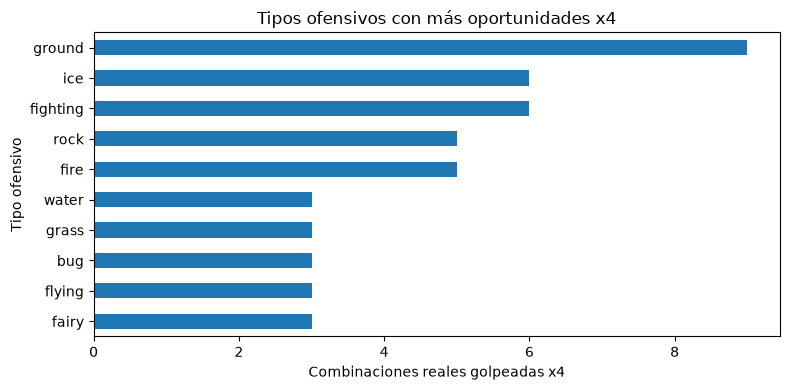

Los tipos ofensivos que más aparecen en esta vista son ground, fighting y ice. Su valor no viene solo de golpear x2 a tipos individuales, sino de amenazar combinaciones dobles reales con daño x4. Esto vuelve esas coberturas relevantes como contexto, aunque la decisión competitiva final depende del movimiento concreto, el usuario del ataque y el estado de la partida.

In [12]:
filas_x4 = []
for atacante in tipos:
    combos = []
    afectados = []
    for d1, d2 in perfiles_dobles:
        if mult(atacante, d1) == 2.0 and mult(atacante, d2) == 2.0:
            perfil = f'{d1} / {d2}'
            combos.append(perfil)
            afectados.extend(perfil_ejemplos.get(perfil, '').split(', '))
    combos = sorted(set(combos))
    afectados = sorted(set(p for p in afectados if p))
    if combos:
        filas_x4.append({
            'tipo_ofensivo': atacante,
            'combinaciones_x4': len(combos),
            'ejemplos_combinaciones': ', '.join(combos[:5]),
            'ejemplos_pokemon_afectados': ', '.join(afectados[:5])
        })

tabla_x4 = pd.DataFrame(filas_x4).sort_values(
    ['combinaciones_x4', 'tipo_ofensivo'],
    ascending=[False, True]
).reset_index(drop=True)

display(tabla_x4.head(15))
if not tabla_x4.empty:
    ax = tabla_x4.head(10).sort_values('combinaciones_x4').plot.barh(
        x='tipo_ofensivo', y='combinaciones_x4', legend=False, figsize=(8, 4)
    )
    ax.set_title('Tipos ofensivos con más oportunidades x4')
    ax.set_xlabel('Combinaciones reales golpeadas x4')
    ax.set_ylabel('Tipo ofensivo')
    plt.tight_layout()
    plt.show()
    tipos_x4 = lista_texto(tabla_x4['tipo_ofensivo'])
    display(Markdown(
        f"Los tipos ofensivos que más aparecen en esta vista son {tipos_x4}. Su valor no viene solo de golpear x2 a tipos individuales, "
        "sino de amenazar combinaciones dobles reales con daño x4. Esto vuelve esas coberturas relevantes como contexto, aunque la decisión competitiva final depende del movimiento concreto, el usuario del ataque y el estado de la partida."
    ))


#### 4.3.4 Resistencias dobles x0.25

También puede ocurrir lo contrario: si ambos tipos de una combinación resisten
el mismo tipo ofensivo, el daño recibido se aproxima a x0.25. Esa resistencia
doble puede ser estratégicamente valiosa porque permite entrar con más seguridad
frente a amenazas concretas. Este cálculo solo se reporta porque el grafo sí
contiene multiplicadores completos en `EFFECTIVENESS.factor`.


,perfil_tipo,resistencias_defensivas_x025,tipos_resistidos_x025,cantidad_pokemon,ejemplos_pokemon
0,fire / steel,5,"bug, fairy, grass, ice, steel",1,heatran
1,dragon / grass,3,"electric, grass, water",5,"appletun, applin, dipplin, flapple, hydrapple"
2,fire / poison,3,"bug, fairy, grass",3,"iron-moth, salandit, salazzle"
3,flying / poison,3,"bug, fighting, grass",3,"crobat, golbat, zubat"
4,poison / steel,3,"bug, fairy, grass",2,"revavroom, varoom"
5,fire / water,3,"fire, ice, steel",1,volcanion
6,bug / flying,2,"fighting, grass",13,"beautifly, butterfree, combee, ledian, ledyba"
7,bug / poison,2,"fighting, grass",12,"ariados, beedrill, dustox, kakuna, scolipede"
8,rock / steel,2,"flying, normal",7,"aggron, aron, bastiodon, lairon, probopass"
9,fire / flying,2,"bug, grass",6,"charizard, fletchinder, ho-oh, moltres, oricorio-baile"


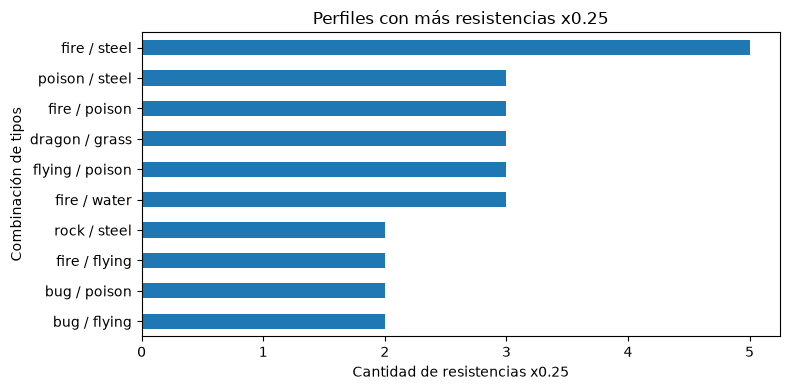

Perfiles como fire / steel, dragon / grass y fire / poison aparecen arriba porque ambos tipos resisten algunos de los mismos ataques. Esa doble resistencia no garantiza viabilidad por sí sola, pero sí puede convertir a estos perfiles en buenas respuestas defensivas frente a amenazas específicas.

In [13]:
if efectividad_completa:
    tabla_x025 = tabla_doble[tabla_doble['defensiva_x025'] > 0][[
        'perfil_tipo', 'defensiva_x025', 'resistencias_x025',
        'cantidad_pokemon', 'ejemplos_pokemon'
    ]].sort_values(['defensiva_x025', 'cantidad_pokemon'], ascending=False).reset_index(drop=True)
    display(mostrar_columnas_claras(tabla_x025, [
        'perfil_tipo', 'defensiva_x025', 'resistencias_x025',
        'cantidad_pokemon', 'ejemplos_pokemon'
    ], n=15))
    if not tabla_x025.empty:
        ax = tabla_x025.head(10).sort_values('defensiva_x025').plot.barh(
            x='perfil_tipo', y='defensiva_x025', legend=False, figsize=(8, 4)
        )
        ax.set_title('Perfiles con más resistencias x0.25')
        ax.set_xlabel('Cantidad de resistencias x0.25')
        ax.set_ylabel('Combinación de tipos')
        plt.tight_layout()
        plt.show()
        perfiles = lista_texto(tabla_x025['perfil_tipo'])
        display(Markdown(
            f"Perfiles como {perfiles} aparecen arriba porque ambos tipos resisten algunos de los mismos ataques. "
            "Esa doble resistencia no garantiza viabilidad por sí sola, pero sí puede convertir a estos perfiles en buenas respuestas defensivas frente a amenazas específicas."
        ))
else:
    display(Markdown(
        "El grafo actual permite observar relaciones de súper efectividad, pero no contiene información suficiente para calcular resistencias x0.5, "
        "resistencias x0.25 o neutralidades x1 de manera confiable. Por eso, esta parte se reporta como una limitación del análisis y como una extensión futura."
    ))


#### 4.3.5 Comparación general entre perfiles individuales y dobles

La comparación final junta perfiles individuales y dobles bajo una misma métrica
de balance ajustado. En los tipos individuales, el balance resume cobertura x2,
resistencias x0.5 y debilidades x2. En los tipos dobles, además se consideran
ventajas ofensivas x4, debilidades x4 y resistencias x0.25. La métrica no busca
ser un modelo perfecto de daño, sino una forma simple de ordenar perfiles para
discusión estratégica.


,categoria_tipo,perfil_tipo,cantidad_pokemon,objetivos_ofensivos_x2,combinaciones_objetivo_x4,objetivos_ofensivos_neutrales_x1,amenazas_defensivas_x2,amenazas_defensivas_x4,resistencias_defensivas_x05,resistencias_defensivas_x025,amenazas_neutrales_x1,balance_ajustado,ejemplos_pokemon
0,Doble,fire / ground,2,8,14,10,1,1,5,0,10,25,"camerupt, numel"
1,Doble,ground / steel,3,7,11,11,4,0,7,1,4,22,"excadrill, iron-treads, steelix"
2,Doble,ground / rock,9,8,14,10,4,2,4,1,6,21,"geodude, golem, graveler, larvitar, onix"
3,Doble,flying / ground,3,8,12,10,1,1,3,0,11,21,"gligar, gliscor, landorus-incarnate"
4,Doble,ground / ice,3,9,15,9,5,0,1,0,11,20,"mamoswine, piloswine, swinub"
5,Doble,fighting / ground,1,8,14,8,6,0,3,1,7,20,great-tusk
6,Doble,fighting / fire,6,7,11,11,4,0,5,1,8,20,"blaziken, combusken, emboar, infernape, monferno"
7,Doble,ground / water,9,6,11,11,0,1,4,0,12,20,"barboach, gastrodon, marshtomp, palpitoad, quagsire"
8,Doble,bug / ground,1,8,12,9,4,0,3,0,10,19,nincada
9,Doble,fire / steel,1,6,7,10,2,1,4,5,5,19,heatran


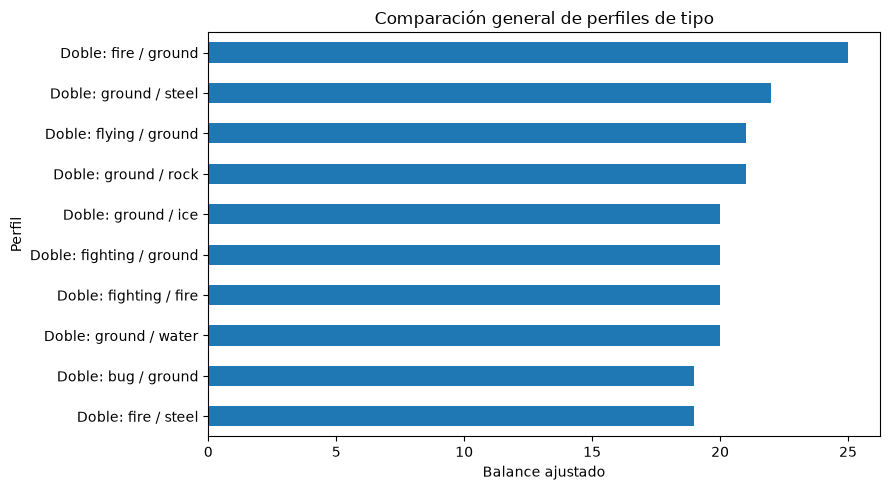

En la comparación general aparecen arriba perfiles como fire / ground, ground / steel y ground / rock. Los perfiles dobles pueden ganar por sumar resistencias y cobertura, pero también pueden caer si introducen amenazas x4. Los perfiles individuales suelen ser más simples de leer: no generan vulnerabilidades dobles, aunque tampoco acceden a las mismas sinergias defensivas u ofensivas de una combinación. La tabla resume el contexto de tipos disponible en el grafo; no pretende ordenar Pokémon completos ni dictar qué perfil es mejor en todos los equipos.

In [14]:
tabla_ind_comp = tabla_individual.assign(
    categoria_tipo='Individual',
    ofensiva_x4=0,
    debilidades_x4=0,
    defensiva_x025=0
)
tabla_dob_comp = tabla_doble.assign(categoria_tipo='Doble')

columnas_comparacion = [
    'categoria_tipo', 'perfil_tipo', 'cantidad_pokemon',
    'ofensiva_x2', 'ofensiva_x4', 'ofensiva_x1',
    'debilidades_x2', 'debilidades_x4',
    'defensiva_x05', 'defensiva_x025', 'defensiva_x1',
    'balance_ajustado', 'ejemplos_pokemon'
]

tabla_general = pd.concat([
    tabla_ind_comp[columnas_comparacion],
    tabla_dob_comp[columnas_comparacion]
], ignore_index=True).sort_values(
    ['balance_ajustado', 'ofensiva_x4', 'debilidades_x4'],
    ascending=[False, False, True]
).reset_index(drop=True)

display(mostrar_columnas_claras(tabla_general, columnas_comparacion, n=20))
if not tabla_general.empty:
    graf = tabla_general.head(10).copy()
    graf['perfil'] = graf['categoria_tipo'] + ': ' + graf['perfil_tipo']
    ax = graf.sort_values('balance_ajustado').plot.barh(
        x='perfil', y='balance_ajustado', legend=False, figsize=(9, 5)
    )
    ax.set_title('Comparación general de perfiles de tipo')
    ax.set_xlabel('Balance ajustado')
    ax.set_ylabel('Perfil')
    plt.tight_layout()
    plt.show()
    mejores = lista_texto(tabla_general['perfil_tipo'])
    display(Markdown(
        f"En la comparación general aparecen arriba perfiles como {mejores}. Los perfiles dobles pueden ganar por sumar resistencias y cobertura, "
        "pero también pueden caer si introducen amenazas x4. Los perfiles individuales suelen ser más simples de leer: no generan vulnerabilidades dobles, "
        "aunque tampoco acceden a las mismas sinergias defensivas u ofensivas de una combinación. La tabla resume el contexto de tipos disponible en el grafo; no pretende ordenar Pokémon completos ni dictar qué perfil es mejor en todos los equipos."
    ))


### 4.4 Grupos o cores que aparecen juntos en equipos

Louvain agrupa Pokémon que aparecen conectados de forma densa en la red de
compañeros. En lenguaje simple, Louvain detecta grupos de Pokémon que tienden a
conectarse entre sí. En esta sección, esos grupos se presentan como hipótesis de
lectura y no como cores confirmados. La red `TEAMMATE_OF` proviene de la capa
competitiva cargada y puede incluir señales más amplias que el alcance estricto
de Gen 9 OU; por eso las etiquetas se mantienen prudentes.


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('teammates', false)"


,modularidad,comunidades_detectadas
0,0.251,1098


,comunidad,nombre_core,confianza_etiqueta,criterio_nombre,tamaño,pokemon_con_uso_ou,proporcion_con_uso_ou,uso_promedio,muestra_pokemon,tipos_frecuentes_en_muestra,movimientos_frecuentes_en_muestra,habilidades_frecuentes_en_muestra,objetos_frecuentes_en_muestra
0,1195,Core defensivo de desgaste,alta,"movimientos de recuperación o desgaste; movimientos frecuentes: hyper-voice, stored-power, skill-swap, block; tipos ...",22,19,0.86,5.67,"[primeape, exeggcute, girafarig, forretress, smeargle, latias, ambipom, heatran, galvantula, volcarona]","[fighting, psychic, grass, normal, steel, bug]","[block, synthesis, leech-seed, skill-swap, psychic-noise, stored-power, guard-swap, hyper-voice]","[harvest, sap-sipper, sturdy, own-tempo, technician]","[colbur-berry, lum-berry, mind-plate, leftovers, heavy-duty-boots]"
1,1261,Core mixto con presencia fuego/planta,alta,"presencia de tipos fire o grass en la muestra; movimientos frecuentes: solar-beam, flamethrower, earthquake, weather...",29,28,0.97,5.54,"[venusaur, charizard, ninetales, ursaring, torkoal, leafeon, probopass, whimsicott, amoonguss, toucannon]","[poison, grass, fire, flying, normal, rock]","[giga-drain, earth-power, growth, sludge-bomb, earthquake, solar-beam, weather-ball, flamethrower]","[chlorophyll, solar-power, blaze, drought, sturdy]","[life-orb, leftovers, focus-sash, heavy-duty-boots, choice-scarf]"
2,487,Core con movimientos de preparación ofensiva,alta,"movimientos de aumento de estadísticas; movimientos frecuentes: dragon-dance, perish-song, substitute, earthquake; t...",43,38,0.88,3.89,"[gyarados, lapras, ditto, blaziken, gardevoir, regirock, regice, registeel, jirachi, staraptor]","[flying, water, ice, normal, fire, fighting]","[scale-shot, waterfall, substitute, crunch, ice-fang, dragon-dance, earthquake, perish-song]","[moxie, intimidate, water-absorb, imposter, speed-boost]","[leftovers, expert-belt, loaded-dice, heavy-duty-boots, chesto-berry]"
3,1022,Core defensivo de desgaste,alta,"movimientos de recuperación o desgaste; movimientos frecuentes: hyper-beam, shadow-ball, discharge, foul-play; tipos...",37,34,0.92,3.22,"[porygon2, tyranitar, hariyama, salamence, infernape, weavile, cresselia, darkrai, zoroark, reuniclus]","[normal, rock, dark, fighting, flying, dragon]","[hyper-beam, trick-room, foul-play, discharge, recover, thunderbolt, shadow-ball, thunder-wave]","[trace, download, sand-stream, guts, intimidate]","[eviolite, assault-vest, heavy-duty-boots, choice-band, smooth-rock]"
4,778,Core con movimientos de preparación ofensiva,alta,"movimientos de aumento de estadísticas; movimientos frecuentes: vacuum-wave, whirlpool, earthquake, hydro-pump; tipo...",33,31,0.94,2.98,"[golduck, poliwrath, zapdos, politoed, kingdra, raikou, entei, suicune, swampert, pelipper]","[water, fighting, flying, electric, dragon, fire]","[nasty-plot, hydro-pump, ice-beam, vacuum-wave, waterfall, earthquake, whirlpool, close-combat]","[swift-swim, water-absorb, pressure, static, drizzle]","[life-orb, rocky-helmet, covert-cloak, sitrus-berry, choice-band]"
5,380,Core con movimientos de preparación ofensiva,alta,"movimientos de aumento de estadísticas; movimientos frecuentes: facade, swords-dance, megahorn, earthquake; tipos fr...",25,21,0.84,2.77,"[heracross, skarmory, latios, gastrodon, mismagius, glaceon, conkeldurr, cobalion, florges, dragalge]","[bug, fighting, flying, steel, psychic, dragon]","[trailblaze, earthquake, knock-off, facade, close-combat, swords-dance, megahorn, stone-edge]","[moxie, guts, sturdy, levitate, sticky-hold]","[choice-scarf, flame-orb, heavy-duty-boots, leftovers, rocky-helmet]"
6,987,Core con soporte y utilidad,alta,"movimientos de control, peligros de entrada o limpieza; movimientos frecuentes: acid-spray, knock-off, flip-turn, su...",25,25,1.00,2.39,"[tentacruel, cloyster, chansey, quagsire, blissey, flygon, hippowdon, gliscor, mamoswine, excadrill]","[water, poison, ice, normal, ground, dragon]","[knock-off, poison-jab, sludge-bomb, acid-spray, fli

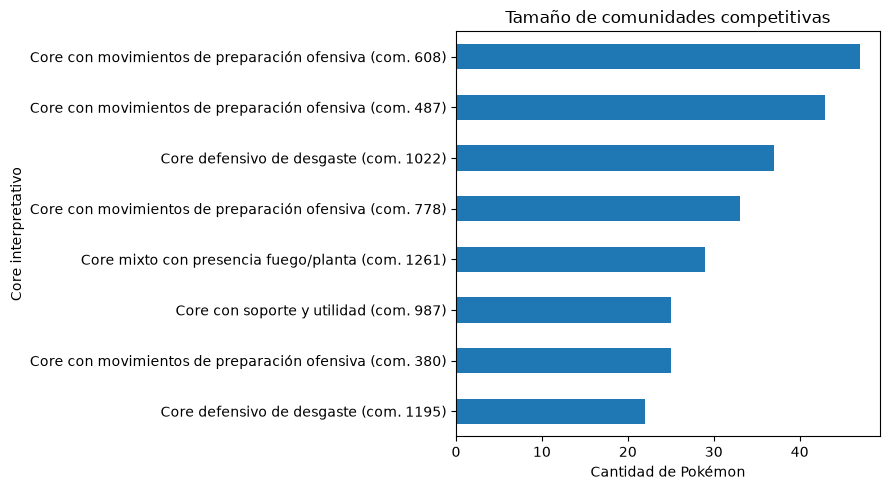

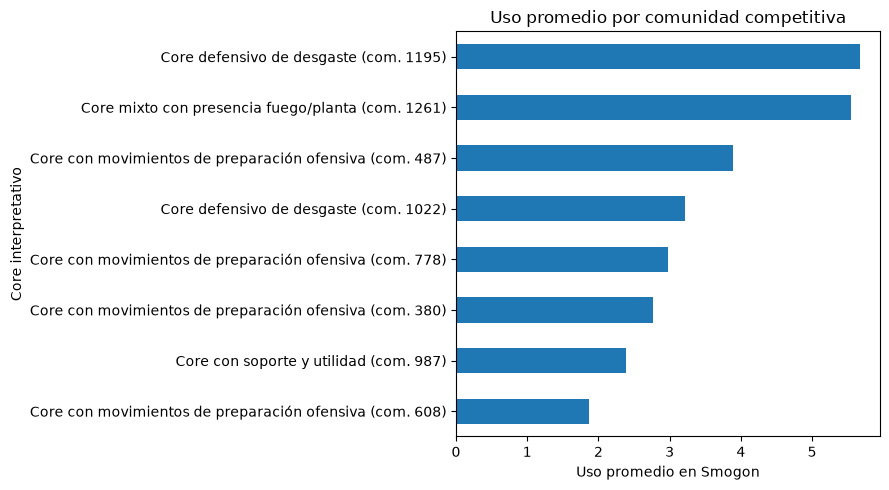

La comunidad 1195 se etiqueta como **Core defensivo de desgaste** con confianza alta a partir de una muestra que incluye primeape, exeggcute, girafarig y forretress. El criterio usado fue: movimientos de recuperación o desgaste; movimientos frecuentes: hyper-voice, stored-power, skill-swap, block; tipos frecuentes: bug, steel, normal, fighting; habilidades observadas: sap-sipper, own-tempo, sturdy; objetos observados: heavy-duty-boots, colbur-berry, leftovers; proporción con uso OU observado: 0.86. Esta etiqueta resume evidencia visible en la tabla, pero no debe leerse como una categoría oficial.

In [15]:
run("CALL gds.graph.drop('teammates', false)")
run('''
CALL gds.graph.project(
  'teammates',
  'Pokemon',
  {
    TEAMMATE_OF: {
      orientation: 'UNDIRECTED'
    }
  }
)
''')

calidad_louvain = df('''
CALL gds.louvain.stats('teammates') YIELD modularity, communityCount
RETURN round(modularity * 1000) / 1000.0 AS modularidad,
       communityCount AS comunidades_detectadas
LIMIT 1
''')
display(calidad_louvain)

res = df('''
CALL gds.louvain.stream('teammates') YIELD nodeId, communityId
WITH communityId, gds.util.asNode(nodeId) AS p
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
OPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)
OPTIONAL MATCH (p)-[:USES_ABILITY]->(ab:Ability)
OPTIONAL MATCH (p)-[:HOLDS_ITEM]->(it:Item)
RETURN communityId AS comunidad,
       count(DISTINCT p) AS tamaño,
       count(DISTINCT CASE WHEN u IS NULL THEN null ELSE p END) AS pokemon_con_uso_ou,
       round((toFloat(count(DISTINCT CASE WHEN u IS NULL THEN null ELSE p END)) / count(DISTINCT p)) * 100) / 100.0 AS proporcion_con_uso_ou,
       round(avg(coalesce(u.usage, 0.0)) * 100) / 100.0 AS uso_promedio,
       collect(DISTINCT p.identifier)[..10] AS muestra_pokemon,
       collect(DISTINCT t.identifier)[..6] AS tipos_frecuentes_en_muestra,
       collect(DISTINCT m.identifier)[..8] AS movimientos_frecuentes_en_muestra,
       collect(DISTINCT ab.identifier)[..5] AS habilidades_frecuentes_en_muestra,
       collect(DISTINCT it.identifier)[..5] AS objetos_frecuentes_en_muestra
ORDER BY uso_promedio DESC, tamaño DESC
LIMIT 8
''')

def nombrar_core(fila):
    tipos = set(fila.get('tipos_frecuentes_en_muestra', []) or [])
    movimientos = set(fila.get('movimientos_frecuentes_en_muestra', []) or [])
    habilidades = set(fila.get('habilidades_frecuentes_en_muestra', []) or [])
    objetos = set(fila.get('objetos_frecuentes_en_muestra', []) or [])

    desgaste = {'protect', 'leech-seed', 'toxic', 'will-o-wisp', 'recover', 'roost', 'synthesis', 'wish', 'soft-boiled'}
    setup = {'swords-dance', 'nasty-plot', 'dragon-dance', 'calm-mind', 'bulk-up', 'quiver-dance', 'shell-smash'}
    control = {'rapid-spin', 'defog', 'stealth-rock', 'spikes', 'toxic-spikes', 'knock-off', 'taunt', 'encore'}
    velocidad = {'u-turn', 'volt-switch', 'agility', 'trailblaze', 'rapid-spin', 'dragon-dance'}

    criterios = []
    if movimientos & desgaste:
        nombre = 'Core defensivo de desgaste'
        criterios.append('movimientos de recuperación o desgaste')
    elif movimientos & setup:
        nombre = 'Core con movimientos de preparación ofensiva'
        criterios.append('movimientos de aumento de estadísticas')
    elif movimientos & control:
        nombre = 'Core con soporte y utilidad'
        criterios.append('movimientos de control, peligros de entrada o limpieza')
    elif movimientos & velocidad:
        nombre = 'Core mixto con presión ofensiva'
        criterios.append('movimientos de pivoteo, velocidad o presión')
    elif 'water' in tipos:
        nombre = 'Core mixto con presencia de tipo agua'
        criterios.append('presencia de tipo water en la muestra')
    elif {'fire', 'grass'} & tipos:
        nombre = 'Core mixto con presencia fuego/planta'
        criterios.append('presencia de tipos fire o grass en la muestra')
    else:
        nombre = 'Core mixto no etiquetable'
        criterios.append('mezcla de Pokémon y herramientas sin patrón dominante claro')

    evidencia = 0
    if movimientos & (desgaste | setup | control | velocidad):
        evidencia += 1
    if tipos:
        evidencia += 1
    if habilidades:
        evidencia += 1
    if objetos:
        evidencia += 1
    if nombre == 'Core mixto no etiquetable':
        confianza = 'baja'
    elif evidencia >= 3 and fila.get('proporcion_con_uso_ou', 0) >= 0.5:
        confianza = 'alta'
    elif evidencia >= 2:
        confianza = 'media'
    else:
        confianza = 'baja'

    partes = criterios
    if movimientos:
        partes.append('movimientos frecuentes: ' + ', '.join(list(movimientos)[:4]))
    if tipos:
        partes.append('tipos frecuentes: ' + ', '.join(list(tipos)[:4]))
    if habilidades:
        partes.append('habilidades observadas: ' + ', '.join(list(habilidades)[:3]))
    if objetos:
        partes.append('objetos observados: ' + ', '.join(list(objetos)[:3]))
    partes.append(f"proporción con uso OU observado: {fila.get('proporcion_con_uso_ou', 0):.2f}")
    return pd.Series({'nombre_core': nombre, 'confianza_etiqueta': confianza, 'criterio_nombre': '; '.join(partes)})

if not res.empty:
    res = pd.concat([res, res.apply(nombrar_core, axis=1)], axis=1)
    res['nombre_grafico'] = res.apply(
        lambda r: f"{r['nombre_core']} (com. {r['comunidad']})",
        axis=1
    )

columnas_core = [
    'comunidad', 'nombre_core', 'confianza_etiqueta', 'criterio_nombre',
    'tamaño', 'pokemon_con_uso_ou', 'proporcion_con_uso_ou', 'uso_promedio',
    'muestra_pokemon', 'tipos_frecuentes_en_muestra',
    'movimientos_frecuentes_en_muestra',
    'habilidades_frecuentes_en_muestra', 'objetos_frecuentes_en_muestra'
]
if not res.empty:
    display(res[columnas_core])
    ax = res.sort_values('tamaño').plot.barh(
        x='nombre_grafico', y='tamaño', legend=False, figsize=(9, 5)
    )
    ax.set_title('Tamaño de comunidades competitivas')
    ax.set_xlabel('Cantidad de Pokémon')
    ax.set_ylabel('Core interpretativo')
    plt.tight_layout()
    plt.show()

    ax = res.sort_values('uso_promedio').plot.barh(
        x='nombre_grafico', y='uso_promedio', legend=False, figsize=(9, 5)
    )
    ax.set_title('Uso promedio por comunidad competitiva')
    ax.set_xlabel('Uso promedio en Smogon')
    ax.set_ylabel('Core interpretativo')
    plt.tight_layout()
    plt.show()

    fila = res.iloc[0]
    muestra = lista_texto(fila['muestra_pokemon'], max_items=4)
    display(Markdown(
        f"La comunidad {fila['comunidad']} se etiqueta como **{fila['nombre_core']}** con confianza {fila['confianza_etiqueta']} a partir de una muestra que incluye {muestra}. "
        f"El criterio usado fue: {fila['criterio_nombre']}. Esta etiqueta resume evidencia visible en la tabla, pero no debe leerse como una categoría oficial."
    ))
else:
    display(res)


El algoritmo entrega comunidades numeradas, pero esos números no tienen
significado competitivo por sí solos. Por eso, en esta versión se conserva la
columna `comunidad` como identificador técnico y se agrega `nombre_core` como
una etiqueta interpretativa. Ese nombre se construye a partir de la evidencia
disponible en la tabla: Pokémon representativos, tipos observados, movimientos
frecuentes y, cuando aparecen, habilidades u objetos. Así, una comunidad deja de
ser solo un número interno y pasa a ser una hipótesis más fácil de leer.

Estas etiquetas no deben entenderse como una clasificación oficial del
metajuego. Funcionan como una ayuda de interpretación: permiten pasar de una
comunidad anónima a una posible lectura sobre su función estratégica, como
soporte, desgaste, presión ofensiva, control o afinidad por ciertos tipos. La
columna `confianza_etiqueta` indica cuánta evidencia visible respalda el nombre:
cuando la muestra no sostiene una lectura clara, la etiqueta se deja como mixta
o no etiquetable.

El gráfico de tamaño muestra cuántos Pokémon agrupa cada comunidad, mientras que
el gráfico de uso promedio permite comparar esa cantidad con una señal de
presencia competitiva. Una comunidad grande no siempre es la más influyente, y
una comunidad de alto uso promedio puede estar formada por menos piezas pero más
presentes en el formato. La modularidad reportada entrega una señal de qué tan
separadas están las comunidades dentro de la red, pero no reemplaza una validación
competitiva externa. Además, si una comunidad incluye muchos Pokémon sin uso OU
observado, debe leerse como una agrupación de la red cargada y no como un core
exclusivo de Gen 9 OU. Para confirmar que un grupo corresponde a un core real
habría que revisar conjuntos de movimientos, objetos, EVs, roles concretos,
replays o documentación competitiva adicional.


### 4.5 Cadenas que explican por qué un Pokémon encaja

Las cadenas explicativas conectan una pieza con recursos y contexto competitivo.
La idea no es listar todas las combinaciones posibles, sino mostrar ejemplos
representativos de cómo el grafo une Pokémon, movimientos, tipos de movimiento,
compañeros frecuentes y señales de uso. Para que el resultado sea más útil, se
limita la repetición de un mismo Pokémon y se priorizan cadenas diversas.


#### 4.5.1 Cadenas explicativas representativas

Cada fila de esta tabla resume una cadena principal para un Pokémon distinto.
Los movimientos y compañeros aparecen como listas, no como filas separadas, para
evitar que una sola pieza muy usada domine todo el análisis.


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=8, column=1, offset=206>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 206, 'line': 8, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, u\nORDER BY u.usage DESC\nLIMIT 12\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(tp:Type)\nWITH p, u, collect(DISTINCT tp.identifier)[..2] AS tipos_pokemon\nCALL {\n  WITH p\n  MATCH (p)-[:RUNS_MOVE]->(m:Move)\n  OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)\n  RETURN collect(DISTINCT m.i

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=15, column=1, offset=451>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 451, 'line': 15, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, u\nORDER BY u.usage DESC\nLIMIT 12\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(tp:Type)\nWITH p, u, collect(DISTINCT tp.identifier)[..2] AS tipos_pokemon\nCALL {\n  WITH p\n  MATCH (p)-[:RUNS_MOVE]->(m:Move)\n  OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)\n  RETURN collect(DISTINCT m

,pokemon,uso_smogon,tipos_pokemon,movimientos_representativos,tipos_de_movimientos,companeros_frecuentes,co_uso_promedio,co_uso_maximo,cadena_explicativa,lectura_estrategica
0,great-tusk,33.73,"[ground, fighting]","[headlong-rush, knock-off, taunt, stealth-rock, rapid-spin]","[ground, dark, rock, normal, fighting]","[gholdengo, kingambit, slowking-galar]",1303.80,1604.8,great-tusk -> headlong-rush / knock-off / taunt / stealth-rock / rapid-spin -> ground / dark / rock / normal / fight...,"Conecta herramientas como headlong-rush, knock-off, taunt (ground, dark, rock) con compañeros frecuentes como gholde..."
1,zamazenta,28.68,[fighting],"[body-press, stone-edge, reflect, close-combat, iron-defense]","[fighting, rock, psychic, steel, normal]","[gholdengo, gliscor, samurott-hisui]",1072.30,1399.4,zamazenta -> body-press / stone-edge / reflect / close-combat / iron-defense -> fighting / rock / psychic / steel / ...,"Conecta herramientas como body-press, stone-edge, reflect (fighting, rock, psychic) con compañeros frecuentes como g..."
2,gholdengo,27.63,"[ghost, steel]","[psyshock, dazzling-gleam, hex, thunder-wave, recover]","[psychic, fairy, ghost, electric, normal]","[dragonite, great-tusk, zamazenta]",1730.13,2186.2,gholdengo -> psyshock / dazzling-gleam / hex / thunder-wave / recover -> psychic / fairy / ghost / electric / normal...,"Conecta herramientas como psyshock, dazzling-gleam, hex (psychic, fairy, ghost) con compañeros frecuentes como drago..."
3,dragonite,25.35,"[flying, dragon]","[dragon-claw, roost, outrage, low-kick, extreme-speed]","[dragon, flying, fighting, normal, ice]","[gholdengo, ting-lu, pecharunt]",1329.97,2186.2,dragonite -> dragon-claw / roost / outrage / low-kick / extreme-speed -> dragon / flying / fighting / normal / ice -...,"Conecta herramientas como dragon-claw, roost, outrage (dragon, flying, fighting) con compañeros frecuentes como ghol..."
4,kingambit,25.27,"[dark, steel]","[low-kick, swords-dance, iron-head, sucker-punch, kowtow-cleave]","[fighting, normal, steel, dark]","[great-tusk, ogerpon-wellspring-mask, kyurem]",1022.27,1430.9,kingambit -> low-kick / swords-dance / iron-head / sucker-punch / kowtow-cleave -> fighting / normal / steel / dark ...,"Conecta herramientas como low-kick, swords-dance, iron-head (fighting, normal, steel) con compañeros frecuentes como..."
5,gliscor,19.39,"[flying, ground]","[earthquake, protect, stealth-rock, agility, toxic-spikes]","[ground, normal, rock, psychic, poison]","[zamazenta, blissey, gholdengo]",1028.80,1218.2,gliscor -> earthquake / protect / stealth-rock / agility / toxic-spikes -> ground / normal / rock / psychic / poison...,"Conecta herramientas como earthquake, protect, stealth-rock (ground, normal, rock) con compañeros frecuentes como za..."
6,ting-lu,17.42,"[ground, dark]","[spikes, earthquake, protect, stealth-rock, taunt]","[ground, normal, rock, dark, steel]","[dragonite, gholdengo, kingambit]",971.43,1262.5,ting-lu -> spikes / earthquake / protect / stealth-rock / taunt -> ground / normal / rock / dark / steel -> dragonit...,"Conecta herramientas como spikes, earthquake, protect (ground, normal, rock) con compañeros frecuentes como dragonit..."
7,kyurem,17.04,"[dragon, ice]","[ice-beam, focus-blast, earth-power, blizzard, dragon-dance]","[ice, fighting, ground, dragon, rock]","[kingambit, slowking-galar, landorus-therian]",587.07,753.0,kyurem -> ice-beam / focus-blast / earth-power / blizzard / dragon-dance -> ice / fighting / ground / dragon / rock ...,"Conecta herramientas como ice-beam, focus-blast, earth-power (ice, fighting, ground) con compañeros frecuentes como ..."
8,ogerpon-wellspring-mask,16.47,"[water, grass]","[substitute, encore, taunt, synthesis, trailblaze]","[normal, dark, grass, ground, fairy]","[kingambit, great-tusk, gholdengo]",805.77,882.9,ogerpon-wellspring-mask -> substitute / encore / taunt / synthesis / trailblaze -> normal / dark / grass / ground / ...,"Conecta herramientas como substitute, encore, taunt (normal, d

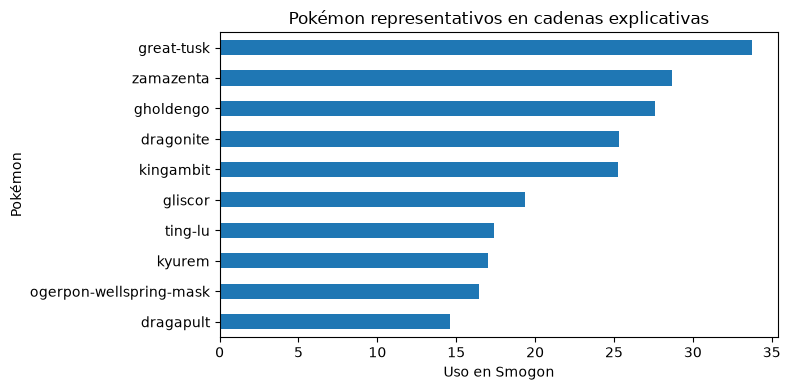

La tabla resume cadenas para Pokémon distintos, como great-tusk, zamazenta y gholdengo. En vez de expandir cada movimiento y cada compañero en filas separadas, cada fila reúne una muestra de herramientas y vínculos competitivos. Esto permite comparar funciones sin que una sola pieza de alto uso ocupe casi toda la salida.

In [16]:
query = '''
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p, u
ORDER BY u.usage DESC
LIMIT 12
OPTIONAL MATCH (p)-[:HAS_TYPE]->(tp:Type)
WITH p, u, collect(DISTINCT tp.identifier)[..2] AS tipos_pokemon
CALL {
  WITH p
  MATCH (p)-[:RUNS_MOVE]->(m:Move)
  OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)
  RETURN collect(DISTINCT m.identifier)[..5] AS movimientos_representativos,
         collect(DISTINCT mt.identifier)[..5] AS tipos_de_movimientos
}
CALL {
  WITH p
  MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)
  WITH aliado, max(coalesce(tm.pct, 0.0)) AS co_uso
  ORDER BY co_uso DESC
  LIMIT 3
  RETURN collect(aliado.identifier) AS companeros_frecuentes,
         round(avg(co_uso) * 100) / 100.0 AS co_uso_promedio,
         round(max(co_uso) * 100) / 100.0 AS co_uso_maximo
}
RETURN p.identifier AS pokemon,
       round(u.usage * 100) / 100.0 AS uso_smogon,
       tipos_pokemon,
       movimientos_representativos,
       tipos_de_movimientos,
       companeros_frecuentes,
       co_uso_promedio,
       co_uso_maximo
ORDER BY uso_smogon DESC
LIMIT 12
'''
res_cadenas = df(query)

def lectura_cadena(fila):
    movimientos = fila['movimientos_representativos'] or []
    tipos_mov = fila['tipos_de_movimientos'] or []
    companeros = fila['companeros_frecuentes'] or []
    mov_txt = ', '.join(movimientos[:3]) if movimientos else 'movimientos no detallados'
    tipos_txt = ', '.join(tipos_mov[:3]) if tipos_mov else 'tipos no detallados'
    comp_txt = ', '.join(companeros[:3]) if companeros else 'compañeros no detallados'
    return (
        f"Conecta herramientas como {mov_txt} ({tipos_txt}) con compañeros frecuentes como {comp_txt}. "
        "La cadena sugiere una función posible dentro de equipos reales, pero no demuestra por sí sola un conjunto exacto."
    )

if not res_cadenas.empty:
    res_cadenas['cadena_explicativa'] = res_cadenas.apply(
        lambda r: (
            f"{r['pokemon']} -> {' / '.join(r['movimientos_representativos'] or [])} "
            f"-> {' / '.join(r['tipos_de_movimientos'] or [])} "
            f"-> {' / '.join(r['companeros_frecuentes'] or [])}"
        ),
        axis=1
    )
    res_cadenas['lectura_estrategica'] = res_cadenas.apply(lectura_cadena, axis=1)

display(res_cadenas)
if not res_cadenas.empty:
    ax = res_cadenas.head(10).sort_values('uso_smogon').plot.barh(
        x='pokemon', y='uso_smogon', legend=False, figsize=(8, 4)
    )
    ax.set_title('Pokémon representativos en cadenas explicativas')
    ax.set_xlabel('Uso en Smogon')
    ax.set_ylabel('Pokémon')
    plt.tight_layout()
    plt.show()
    ejemplos = lista_texto(res_cadenas['pokemon'])
    display(Markdown(
        f"La tabla resume cadenas para Pokémon distintos, como {ejemplos}. En vez de expandir cada movimiento y cada compañero en filas separadas, "
        "cada fila reúne una muestra de herramientas y vínculos competitivos. Esto permite comparar funciones sin que una sola pieza de alto uso ocupe casi toda la salida."
    ))


La tabla no debe leerse como una receta exacta de equipo, sino como una
explicación de conexiones. Para cada Pokémon, el grafo permite unir su presencia
competitiva con algunos movimientos relevantes y con compañeros que aparecen
asociados en la red. Esto ayuda a pasar de una pregunta simple, como qué
movimientos aprende o usa un Pokémon, a una pregunta más estratégica: qué tipo
de función puede cumplir y con qué otras piezas suele conectarse.

Los movimientos listados no implican necesariamente un conjunto competitivo completo.
Funcionan como evidencia disponible en el grafo para describir capacidades
posibles, mientras que los compañeros frecuentes aportan contexto de equipo.
Para confirmar un conjunto real habría que revisar objeto, EVs, habilidad,
formato y uso concreto en partidas.


#### 4.5.2 Ejemplos de cadenas concretas

La tabla siguiente baja un nivel de detalle y muestra ejemplos específicos de
Pokémon, movimiento y compañero frecuente. Se limita la repetición para mantener
diversidad: primero se ordenan las posibles cadenas por uso y co-uso, y luego se
conserva como máximo una fila principal por Pokémon.


In [17]:
query = '''
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p, u
ORDER BY u.usage DESC
LIMIT 18
MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)
RETURN p.identifier AS pokemon,
       round(u.usage * 100) / 100.0 AS uso_smogon,
       m.identifier AS movimiento_usado,
       mt.identifier AS tipo_del_movimiento,
       aliado.identifier AS companero_frecuente,
       round(coalesce(tm.pct, 0.0) * 100) / 100.0 AS co_uso
ORDER BY uso_smogon DESC, co_uso DESC
LIMIT 80
'''
ejemplos_cadenas = df(query)
columnas_ejemplos = ['pokemon', 'movimiento_usado', 'tipo_del_movimiento',
                    'companero_frecuente', 'co_uso', 'explicacion_cadena']
if not ejemplos_cadenas.empty:
    ejemplos_cadenas = (
        ejemplos_cadenas
        .dropna(subset=['movimiento_usado', 'companero_frecuente'])
        .drop_duplicates(subset=['pokemon'])
        .head(8)
        .reset_index(drop=True)
    )
    ejemplos_cadenas['explicacion_cadena'] = ejemplos_cadenas.apply(
        lambda r: (
            f"{r['pokemon']} se conecta con {r['movimiento_usado']} de tipo {r['tipo_del_movimiento']} "
            f"y con {r['companero_frecuente']} como compañero frecuente. Esto sugiere una relación entre herramienta, cobertura o utilidad y contexto competitivo."
        ),
        axis=1
    )
else:
    ejemplos_cadenas = pd.DataFrame(columns=columnas_ejemplos)
display(ejemplos_cadenas[columnas_ejemplos])
if not ejemplos_cadenas.empty:
    ejemplos = "; ".join(
        f"{r['pokemon']} -> {r['movimiento_usado']} -> {r['companero_frecuente']}"
        for _, r in ejemplos_cadenas.head(2).iterrows()
    )
    display(Markdown(
        f"Ejemplos como {ejemplos} muestran cómo una cadena concreta puede justificar una hipótesis estratégica. "
        "No se afirma causalidad: el grafo no prueba que el movimiento cause la asociación con el compañero, pero sí muestra que esas entidades aparecen conectadas en la capa competitiva."
    ))


,pokemon,movimiento_usado,tipo_del_movimiento,companero_frecuente,co_uso,explicacion_cadena
0,great-tusk,body-press,fighting,gholdengo,1604.8,great-tusk se conecta con body-press de tipo fighting y con gholdengo como compañero frecuente. Esto sugiere una rel...


Ejemplos como great-tusk -> body-press -> gholdengo muestran cómo una cadena concreta puede justificar una hipótesis estratégica. No se afirma causalidad: el grafo no prueba que el movimiento cause la asociación con el compañero, pero sí muestra que esas entidades aparecen conectadas en la capa competitiva.

Estas cadenas concretas sirven como ejemplos interpretables, no como prueba
definitiva de causalidad. El valor del grafo está en unir información que en
tablas separadas quedaría aislada: presencia competitiva, movimientos, tipos de
movimiento y compañeros frecuentes. Al limitar la repetición de Pokémon, la
sección muestra una variedad mayor de posibles funciones estratégicas y evita
que el análisis quede dominado por una sola pieza muy usada.


### 4.6 ¿Puede el grafo anticipar compatibilidad competitiva entre Pokémon usando solo información no derivada del uso competitivo?

Esta pregunta evalúa el valor predictivo del grafo bajo una restricción
metodológica más exigente. No se busca construir automáticamente un equipo
perfecto de seis Pokémon, sino analizar si atributos y relaciones no derivadas
directamente del uso observado podrían ayudar a estimar compatibilidad
competitiva entre Pokémon. En este contexto, predecir compatibilidad significa
distinguir pares que podrían tener sentido dentro de una estrategia de pares que
no muestran una señal funcional clara.

La advertencia central es la fuga de información. Si el objetivo fuera predecir
una relación de equipo como `TEAMMATE_OF`, no se deberían usar como variables de
entrada esa misma relación, su grado, PageRank o comunidades calculadas sobre
ella. Tampoco deberían usarse directamente `USED_IN`, `uso_smogon`, co-uso ni
otras señales derivadas del uso competitivo observado. Esas relaciones pueden
servir como etiqueta o como evaluación, pero no como explicación independiente
del modelo.


#### 4.6.1 Variables usadas y excluidas para evitar fuga de información

La siguiente tabla separa las variables que sí se usan en el modelo principal de
las que se excluyen para evitar fuga de información. `TEAMMATE_OF` se usa como
etiqueta a predecir, no como entrada del modelo. Del mismo modo, las señales de
uso competitivo se dejan fuera porque están demasiado cerca del fenómeno que se
quiere anticipar.


In [18]:
variables_fuga = pd.DataFrame([
    {
        "grupo": "Stats base",
        "ejemplos": "BST, HP, Attack, Defense, Sp. Atk, Sp. Def, Speed",
        "se_usa_en_modelo": "Sí",
        "motivo": "Son atributos propios del Pokémon y no derivan del uso competitivo observado."
    },
    {
        "grupo": "Tipos",
        "ejemplos": "tipos de cada Pokémon, tipos compartidos, perfil de tipo",
        "se_usa_en_modelo": "Sí",
        "motivo": "Es información estructural del Pokémon y permite comparar compatibilidad básica sin mirar equipos observados."
    },
    {
        "grupo": "Movepool disponible",
        "ejemplos": "`CAN_LEARN`, movimientos compartidos, Jaccard de movimientos aprendibles",
        "se_usa_en_modelo": "Sí",
        "motivo": "Aproxima similitud funcional sin usar movimientos observados en equipos competitivos."
    },
    {
        "grupo": "Habilidades",
        "ejemplos": "habilidades compartidas, Jaccard de habilidades",
        "se_usa_en_modelo": "Sí",
        "motivo": "Son atributos propios del Pokémon y pueden reflejar funciones parecidas o complementarias."
    },
    {
        "grupo": "Uso competitivo",
        "ejemplos": "`USED_IN`, `uso_smogon`",
        "se_usa_en_modelo": "No",
        "motivo": "Deriva del mismo fenómeno competitivo que se quiere evaluar y puede inflar artificialmente el desempeño."
    },
    {
        "grupo": "Relaciones de equipo",
        "ejemplos": "`TEAMMATE_OF`, grado, PageRank o comunidades sobre `TEAMMATE_OF`",
        "se_usa_en_modelo": "No",
        "motivo": "`TEAMMATE_OF` es la variable objetivo; usarla o usar derivados suyos sería fuga de información."
    },
    {
        "grupo": "Movimientos usados competitivamente",
        "ejemplos": "`RUNS_MOVE` cuando proviene de Smogon",
        "se_usa_en_modelo": "No",
        "motivo": "Puede reflejar directamente decisiones observadas en el metajuego que se intenta predecir."
    },
])

display(variables_fuga)


,grupo,ejemplos,se_usa_en_modelo,motivo
0,Stats base,"BST, HP, Attack, Defense, Sp. Atk, Sp. Def, Speed",Sí,Son atributos propios del Pokémon y no derivan del uso competitivo observado.
1,Tipos,"tipos de cada Pokémon, tipos compartidos, perfil de tipo",Sí,Es información estructural del Pokémon y permite comparar compatibilidad básica sin mirar equipos observados.
2,Movepool disponible,"`CAN_LEARN`, movimientos compartidos, Jaccard de movimientos aprendibles",Sí,Aproxima similitud funcional sin usar movimientos observados en equipos competitivos.
3,Habilidades,"habilidades compartidas, Jaccard de habilidades",Sí,Son atributos propios del Pokémon y pueden reflejar funciones parecidas o complementarias.
4,Uso competitivo,"`USED_IN`, `uso_smogon`",No,Deriva del mismo fenómeno competitivo que se quiere evaluar y puede inflar artificialmente el desempeño.
5,Relaciones de equipo,"`TEAMMATE_OF`, grado, PageRank o comunidades sobre `TEAMMATE_OF`",No,`TEAMMATE_OF` es la variable objetivo; usarla o usar derivados suyos sería fuga de información.
6,Movimientos usados competitivamente,`RUNS_MOVE` cuando proviene de Smogon,No,Puede reflejar directamente decisiones observadas en el metajuego que se intenta predecir.


#### 4.6.2 Experimento predictivo 

El experimento principal usa `TEAMMATE_OF` como etiqueta: un par positivo
corresponde a dos Pokémon conectados por esa relación, mientras que un par
negativo corresponde a dos Pokémon del mismo universo de candidatos que no están
conectados por `TEAMMATE_OF`. Los negativos se muestrean dentro de los Pokémon
que aparecen en alguna relación de compañeros, en proporción 1:1 con los
positivos. Esto evita una comparación demasiado fácil contra Pokémon
completamente ajenos al universo competitivo observado.

El modelo se entrena con un split reproducible de entrenamiento y prueba
(`random_state=42`) y usa un clasificador simple de bosque aleatorio. El cuaderno
no ejecuta `analysis/graph_ml_integrated.py`; solo muestra el archivo de métricas
generado externamente por ese script.


,bloque,modelo,n_variables,auc,ap,train_positivos,train_negativos,test_positivos,test_negativos
0,Baseline de stats,RandomForestClassifier,4,0.612,0.612,1341,1341,447,447
1,Stats + tipos,RandomForestClassifier,7,0.625,0.632,1341,1341,447,447
2,Stats + movepool disponible,RandomForestClassifier,8,0.677,0.668,1341,1341,447,447
3,Grafo base sin fuga,RandomForestClassifier,20,0.687,0.692,1341,1341,447,447


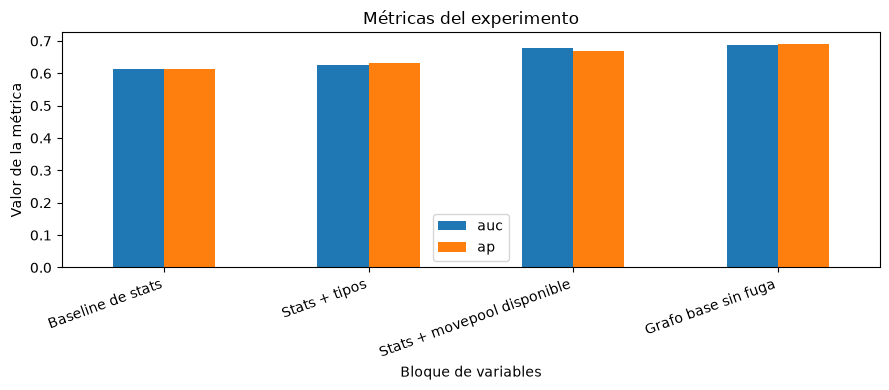

El experimento usa 1788 pares positivos y 1788 pares negativos. El mejor bloque fue `Grafo base sin fuga`, con AUC=0.687 y AP=0.692. Estas métricas se calculan sin usar `TEAMMATE_OF`, uso Smogon ni señales competitivas derivadas como variables de entrada.

Las métricas de ML se calculan fuera de este cuaderno con analysis/graph_ml_integrated.py.


In [19]:
import json
import os

rutas_resultados_ml = [
    os.path.join('analysis', 'ml_teammate_safe_results.json'),
    'ml_teammate_safe_results.json',
]
resultados_ml_seguro = {}
for ruta in rutas_resultados_ml:
    if os.path.exists(ruta):
        with open(ruta, 'r', encoding='utf-8') as f:
            resultados_ml_seguro = json.load(f)
        break

if resultados_ml_seguro.get('resultados'):
    metricas_seguras = pd.DataFrame(resultados_ml_seguro['resultados'])
    columnas_metricas = [
        'bloque', 'modelo', 'n_variables', 'auc', 'ap',
        'train_positivos', 'train_negativos', 'test_positivos', 'test_negativos'
    ]
    display(metricas_seguras[columnas_metricas])

    ax = metricas_seguras.set_index('bloque')[['auc', 'ap']].plot.bar(figsize=(9, 4))
    ax.set_title('Métricas del experimento')
    ax.set_xlabel('Bloque de variables')
    ax.set_ylabel('Valor de la métrica')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

    mejor = metricas_seguras.sort_values(['auc', 'ap'], ascending=False).iloc[0]
    display(Markdown(
        "El experimento usa " + str(resultados_ml_seguro.get('pares_positivos')) + " pares positivos y "
        + str(resultados_ml_seguro.get('pares_negativos')) + " pares negativos. "
        + "El mejor bloque fue `" + str(mejor['bloque']) + "`, con AUC="
        + format(float(mejor['auc']), '.3f') + " y AP=" + format(float(mejor['ap']), '.3f') + ". "
        + "Estas métricas se calculan sin usar `TEAMMATE_OF`, uso Smogon ni señales competitivas derivadas como variables de entrada."
    ))
else:
    display(Markdown(
        "No se encontró `analysis/ml_teammate_safe_results.json`. "
        "Ejecuta `analysis/graph_ml_integrated.py` fuera del cuaderno para generar las métricas del experimento sin fuga."
    ))

print("Las métricas de ML se calculan fuera de este cuaderno con analysis/graph_ml_integrated.py.")


#### 4.6.3 Control con fuga de información

Durante el desarrollo del análisis se evaluó una versión inicial del experimento que incorporaba señales competitivas demasiado cercanas al objetivo, como relaciones de compañeros, uso observado, movimientos usados en Smogon y otras variables derivadas del mismo fenómeno que se buscaba predecir. Aunque ese enfoque podía producir resultados aparentemente mejores, no era metodológicamente adecuado para evaluar predicción independiente, porque el modelo recibía información muy próxima a la respuesta.

Por esa razón, el reporte no usa esa versión como evidencia principal. En su lugar, la pregunta 6 se reformula como un experimento sin fuga de información, donde la relación TEAMMATE_OF se usa como etiqueta a predecir, pero no como variable de entrada ni a través de métricas derivadas de ella.

La comparación es útil porque muestra por qué el control de fuga es necesario. Un resultado más moderado en el experimento sin fuga no debe interpretarse como un fracaso metodológico; al contrario, es esperable cuando el modelo deja de mirar señales cercanas a la respuesta. Si aun así el desempeño queda por encima del azar, la conclusión es más confiable aunque sea más modesta.


#### 4.6.4 Interpretación de AUC, AP y resultados

AUC mide qué tan bien el modelo separa pares de Pokémon observados como compatibles de pares no conectados por `TEAMMATE_OF`. Un valor cercano a 0.5 indica un comportamiento similar a adivinar al azar, mientras que valores más altos muestran una mejor capacidad de separación. AP resume qué tan bien el modelo prioriza los casos positivos, lo que es útil en este problema porque existen muchas combinaciones posibles de Pokémon y solo una parte pequeña aparece como vínculo competitivo observado.

En términos simples, estas métricas no deben leerse como una nota ni como un porcentaje de acierto directo. Por ejemplo, un AUC de 0.68 no significa que el modelo “acierta un 68% de los equipos”, sino que, al comparar pares compatibles y no compatibles, el modelo tiende a ordenar mejor los pares realmente observados como compatibles. De la misma forma, un AP cercano a 0.69 indica que el modelo logra priorizar varios casos positivos por sobre combinaciones no observadas, aunque todavía está lejos de ser una predicción perfecta.

En este experimento, las métricas deben leerse como una evaluación controlada y conservadora. El modelo no usa `TEAMMATE_OF`, Smogon, relaciones de compañeros, movimientos usados competitivamente ni métricas derivadas de equipos observados como variables de entrada. En cambio, se apoya en atributos propios del Pokémon y relaciones base del grafo, como tipos, estadísticas, habilidades y movimientos aprendibles mediante `CAN_LEARN`.

Por eso, el objetivo no es obtener una predicción perfecta de equipos competitivos, sino evaluar si el grafo base contiene una señal parcial de compatibilidad. Si el bloque completo sin fuga supera al baseline de estadísticas, la lectura razonable es que combinar tipos, habilidades y movepool disponible aporta más información que mirar estadísticas aisladas.

El resultado debe interpretarse con cautela: no significa que el modelo pueda construir equipos completos ni reemplazar criterio competitivo experto. Más bien, muestra que el grafo puede transformar información dispersa en variables comparables para estimar compatibilidad de manera más informada. En este contexto, un desempeño moderado es metodológicamente más defendible que una métrica artificialmente alta obtenida usando señales demasiado cercanas a la respuesta.



## 5. Machine Learning integrado

El bloque de machine learning se conserva como una síntesis del experimento predictivo de la pregunta 6. La lógica completa vive en `analysis/graph_ml_integrated.py` y debe ejecutarse por separado cuando se quiera reproducir el experimento completo.

El objetivo del experimento es evaluar si atributos y relaciones base del grafo permiten anticipar parcialmente la compatibilidad competitiva entre pares de Pokémon, usando `TEAMMATE_OF` como etiqueta a predecir. Para evitar fuga de información, el modelo no utiliza como entrada relaciones de compañeros, uso competitivo observado, movimientos usados en Smogon ni métricas derivadas directamente de la red competitiva que se busca predecir.

El resumen compara distintos bloques de variables:

* baseline de estadísticas base;
* estadísticas más tipos;
* estadísticas más movepool disponible mediante `CAN_LEARN`;
* grafo base sin fuga, combinando estadísticas, tipos, habilidades y movepool disponible.

No se ejecuta el archivo completo dentro del cuaderno para evitar aumentar el tiempo de `nbconvert` y para mantener separado el reporte narrativo del experimento reproducible. La interpretación de las métricas debe leerse de forma metodológicamente conservadora: el experimento no busca demostrar una predicción perfecta de equipos, sino evaluar si el grafo base contiene una señal parcial de compatibilidad sin usar directamente la respuesta como entrada.



## 6. Conclusiones

El grafo integrado funciona como un motor de razonamiento competitivo porque
conecta recursos, roles y relaciones de equipo. La centralidad muestra qué
Pokémon organizan la red; la similitud por movimientos usados competitivamente
sugiere sustitutos para revisión; el cuadro de tipos entrega contexto estructural
al cruzar reglas conocidas con Pokémon reales; las comunidades de `TEAMMATE_OF`
formulan hipótesis de cores; y las rutas heterogéneas explican por qué una pieza
encaja en una estrategia.

El aporte principal frente a una lectura tabular es relacional. Una tabla puede
ordenar por uso, ataque o velocidad; el grafo permite ver cómo una decisión se
conecta con compañeros, cobertura, respuestas defensivas y patrones de co-ocurrencia. Por eso
los resultados deben leerse como apoyo a decisiones estratégicas, no como una
lista automática de mejores Pokémon.

El valor del proyecto no depende solo de ML. La mayor parte del reporte se apoya
en consultas complejas: agregaciones de conectividad, similitud funcional,
perfiles de tipo y recorridos explicativos. El algoritmo de comunidades se usa
solo para la pregunta 4 como análisis estructural exploratorio, no como
predicción. Recién en la pregunta 6 aparece un experimento supervisado, separado
del resto y diseñado para controlar fuga de información.

La revisión metodológica también muestra un límite importante: las señales de uso
competitivo son valiosas para describir el metajuego, pero pueden producir fuga
si se usan para predecir la misma viabilidad o relación de equipo de la que
provienen. Por eso, el resultado antiguo con grafo competitivo se conserva solo
como control de fuga probable. La versión revisada incorpora un experimento para
predecir `TEAMMATE_OF` con variables no derivadas de `TEAMMATE_OF`, `USED_IN` ni
uso Smogon, lo que entrega una evaluación más sobria pero metodológicamente más
defendible.

Como alcance temporal, las conclusiones corresponden a Gen 9 OU / Scarlet &
Violet / Smogon. Pokémon Champions puede cambiar el metajuego, por lo que una
extensión natural del proyecto es actualizar la capa competitiva con esos datos
y volver a evaluar centralidades, sustitutos, cores y métricas.


In [20]:
driver.close()
print('Conexión a Neo4j cerrada. Reporte integrado finalizado.')


Conexión a Neo4j cerrada. Reporte integrado finalizado.
